# 07 — DOMINANT vs GAD-NR: Grafo Bipartito (MG)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo bipartito
miembro-grupo `MG` del dataset Meetup Tennessee, replicando la metodología de los
notebooks 05 (grafo M) y 06 (grafo G) con las adaptaciones necesarias para un grafo
bipartito heterogéneo.

## Características del grafo MG

| Aspecto | Valor |
|---|---|
| Nodos totales | 25.233 (24.631 miembros + 602 grupos) |
| Aristas únicas | 45.583 |
| Features/nodo | 38 (3 de miembro + 35 de grupo, con zero-padding) |
| Densidad | 0.0031 |
| Componentes conexas | 25 (componente principal: 99.8% de los nodos) |

## Diferencias clave respecto a M y G

El grafo MG presenta tres diferencias fundamentales respecto a los grafos anteriores:

1. **Heterogeneidad de nodos.** Hay dos tipos de nodos con perfiles de features completamente
   distintos. Los nodos miembro tienen features en las columnas 0-2 y ceros en 3-37; los nodos
   grupo tienen ceros en 0-2 y features en 3-37. Los modelos no conocen esta distinción —
   tratan todos los nodos igual.

2. **Peso de arista semánticamente distinto.** El peso representa el número de eventos del
   grupo a los que ha asistido el miembro — la única métrica de **actividad real** del dataset.
   A diferencia de M (grupos compartidos) y G (miembros compartidos), aquí el peso tiene un
   significado de comportamiento directo.

3. **Análisis enriquecido.** Además del análisis estándar de los notebooks anteriores, el MG
   permite cruzar los scores de anomalía con los perfiles de comportamiento del EDA
   (miembros inactivos, exploradores, fieles, hiperactivos) y con los ratios de actividad
   de los grupos (grupos fantasma, grupos truncados).

## Esquema del notebook

| Sección | Contenido |
|---|---|
| 0 | Imports y configuración |
| 1 | Carga del grafo MG |
| 2 | Fundamento teórico |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Comparativa por tipo de señal |
| 6 | Spotlight — candidatos individuales del EDA |
| 7 | Comparativa general (heatmap + crosstab) |
| 8 | Análisis enriquecido del bipartito |
| 9 | Visualización t-SNE (5 vistas por modelo) |
| 10 | Guardado de resultados |


## 0. Imports y configuración

In [1]:
%matplotlib inline

import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from scipy.stats import rankdata
from torch_geometric.data import Data
from pygod.detector import DOMINANT

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')


c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo MG

Cargamos el objeto `Data` del grafo MG generado en el notebook `04_feature_engineering.ipynb`.
El grafo MG tiene una estructura especial: los nodos están indexados con los miembros primero
(índices 0 a n_members-1) y los grupos después (índices n_members a n_members+n_groups-1).
Los IDs tienen prefijo `member_` o `group_` para evitar colisiones.

**Nota sobre la componente principal.** El grafo MG no es conexo — tiene 25 componentes
conexas, pero la componente principal concentra el 99.8% de los nodos (25.171 de 25.233).
Los modelos se entrenan sobre el grafo completo incluyendo las componentes aisladas.


In [2]:
data_MG = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_MG.pt'), weights_only=False)
print(data_MG)
print(f'\nNodos totales  : {data_MG.num_nodes}')
print(f'Aristas únicas : {data_MG.num_edges // 2}')
print(f'Features/nodo  : {data_MG.num_node_features}')
print(f'Miembros       : {data_MG.n_members}')
print(f'Grupos         : {data_MG.n_groups}')

# Guardamos IDs y separación de tipos antes de limpiar
node_ids  = data_MG.node_ids   # lista con prefijo member_/group_
n_members = data_MG.n_members
n_groups  = data_MG.n_groups

# Objeto limpio para PyGOD — solo x y edge_index
data_MG_clean = Data(
    x=data_MG.x,
    edge_index=data_MG.edge_index,
)
print(f'\ndata_MG_clean: {data_MG_clean}')


Data(x=[25233, 38], edge_index=[2, 91166], edge_weight=[91166], node_ids=[25233], n_members=24631, n_groups=602)

Nodos totales  : 25233
Aristas únicas : 45583
Features/nodo  : 38
Miembros       : 24631
Grupos         : 602

data_MG_clean: Data(x=[25233, 38], edge_index=[2, 91166])


In [3]:
# Metadatos para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))
meta_groups  = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-groups.csv'))
meta_events  = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-events.csv'))
mg_edges     = pd.read_csv(os.path.join(PROCESSED_PATH, 'member-to-group-edges.csv'))

# DataFrame base con todos los nodos
# Separamos miembros y grupos para enriquecer con sus metadatos respectivos
member_raw_ids = [int(nid.replace('member_', '')) for nid in node_ids[:n_members]]
group_raw_ids  = [int(nid.replace('group_',  '')) for nid in node_ids[n_members:]]

# DataFrame de miembros
base_members = pd.DataFrame({
    'node_id': node_ids[:n_members],
    'raw_id':  member_raw_ids,
    'idx':     range(n_members),
    'node_type': 'member',
})
base_members = base_members.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    left_on='raw_id', right_on='member_id', how='left'
).drop(columns=['member_id'])

# DataFrame de grupos
base_groups = pd.DataFrame({
    'node_id': node_ids[n_members:],
    'raw_id':  group_raw_ids,
    'idx':     range(n_members, n_members + n_groups),
    'node_type': 'group',
})
base_groups = base_groups.merge(
    meta_groups[['group_id', 'group_name', 'category_name', 'num_members']],
    left_on='raw_id', right_on='group_id', how='left'
).drop(columns=['group_id'])
base_groups = base_groups.rename(columns={'group_name': 'name'})

# DataFrame unificado
base_df = pd.concat([base_members, base_groups], ignore_index=True)

# Grado de cada nodo
edge_src = data_MG.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_MG.num_nodes) // 2
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
print(f'Miembros: {(base_df.node_type == "member").sum()}')
print(f'Grupos  : {(base_df.node_type == "group").sum()}')
base_df.head()


base_df: (25233, 10)
Miembros: 24631
Grupos  : 602


,node_id,raw_id,idx,node_type,name,city,state,category_name,num_members,degree
0,member_100010812,100010812,0,member,Molly Kathleen Thomas,Bowling Green,KY,NaN,NaN,0
1,member_10001741,10001741,1,member,Richard L. Carson,Murfreesboro,TN,NaN,NaN,0
2,member_1000328,1000328,2,member,mclean61_65,Lakewood,OH,NaN,NaN,0
3,member_10003439,10003439,3,member,benji,Nashville,TN,NaN,NaN,0
4,member_100064382,100064382,4,member,Amy Door,Grandville,MI,NaN,NaN,1


## 2. Fundamento teórico

El fundamento teórico de DOMINANT y GAD-NR está documentado en detalle en el notebook 05
(grafo M) y se resume brevemente en el notebook 06 (grafo G). Se omite aquí para evitar
repetición — se asume que el lector ha revisado los notebooks anteriores.

Las hipótesis para este grafo, basadas en los resultados de M y G, son:

1. **El curriculum de GAD-NR producirá los mismos lambdas finales** (0.01/7.6/2.4·10⁻⁵)
   que en M y G — el mecanismo es invariante al grafo según lo observado.

2. **`gadnr_feat` quedará degenerada** igual que en G — con 38 features el curriculum
   sobreoptimizará el decoder de features.

3. **La señal estructural será menos coherente entre modelos que en G** (grafo más grande
   y heterogéneo) pero posiblemente más que en M.

4. **La heterogeneidad de nodos** puede producir clusters diferenciados en el t-SNE que
   no aparecían en M ni en G.

Los resultados del entrenamiento confirmarán o rechazarán estas hipótesis en la sección 4.1.


## 3. Entrenamiento de DOMINANT

Configuración análoga a los notebooks anteriores. El peso `weight=0.5` equilibra estructura
y atributos — con 38 features heterogéneas (3 de miembro + 35 de grupo con zero-padding)
no hay razón para priorizar una dimensión sobre la otra.


In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.5,         # equilibrio estructura/atributo con 38 features heterogéneas
    contamination=0.05,
    lr=0.004,
    epoch=300,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo MG...')
dominant.fit(data_MG_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')


Entrenando DOMINANT sobre el grafo MG...
Epoch 0000: Loss 4.4584 |  | Time 3.06
Epoch 0001: Loss 1.9528 |  | Time 1.36
Epoch 0002: Loss 1.6758 |  | Time 1.89
Epoch 0003: Loss 1.6917 |  | Time 1.90
Epoch 0004: Loss 1.6828 |  | Time 1.88
Epoch 0005: Loss 1.5938 |  | Time 1.89
Epoch 0006: Loss 1.4849 |  | Time 1.87
Epoch 0007: Loss 1.4049 |  | Time 1.87
Epoch 0008: Loss 1.3549 |  | Time 1.87
Epoch 0009: Loss 1.3207 |  | Time 1.88
Epoch 0010: Loss 1.2935 |  | Time 1.87
Epoch 0011: Loss 1.2710 |  | Time 1.87
Epoch 0012: Loss 1.2532 |  | Time 1.86
Epoch 0013: Loss 1.2400 |  | Time 1.87
Epoch 0014: Loss 1.2303 |  | Time 1.92
Epoch 0015: Loss 1.2228 |  | Time 1.90
Epoch 0016: Loss 1.2167 |  | Time 1.87
Epoch 0017: Loss 1.2111 |  | Time 1.88
Epoch 0018: Loss 1.2056 |  | Time 1.86
Epoch 0019: Loss 1.1998 |  | Time 1.86
Epoch 0020: Loss 1.1936 |  | Time 1.86
Epoch 0021: Loss 1.1872 |  | Time 1.87
Epoch 0022: Loss 1.1806 |  | Time 1.86
Epoch 0023: Loss 1.1740 |  | Time 1.88
Epoch 0024: Loss 1.1675

In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """Extrae los scores de estructura y atributo de DOMINANT."""
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_MG_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


DOM struct — min=0.8045, max=30.6029, mean=1.3893
DOM attr   — min=0.0047,  max=59.3736,  mean=0.3752

Verificación — correlación con decision_score_: 0.999610
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_score_distribution_MG.png


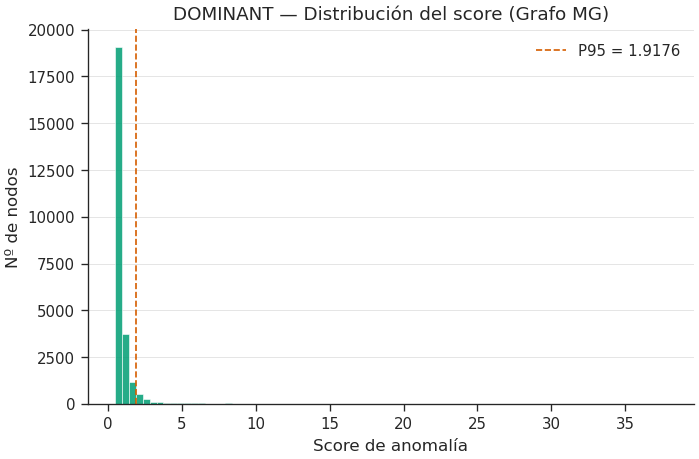

In [6]:
# Distribución del score de DOMINANT
dom_score = dominant.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(dom_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(dom_score, 95)
ax.axvline(p95_dom, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — Distribución del score (Grafo MG)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '07_dominant_score_distribution_MG.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_score_distributions_MG.png


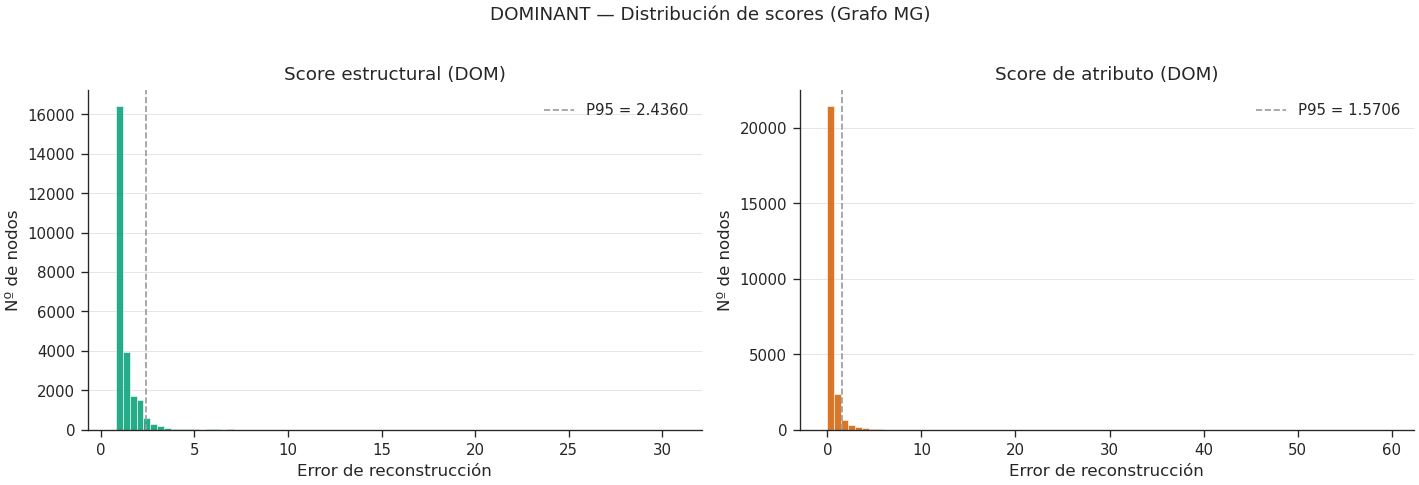

Correlación Spearman struct vs attr (DOMINANT): ρ = 0.5661


In [7]:
# Distribuciones de los dos scores de DOMINANT — separadas por tipo de nodo
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['MG'], PALETTE['anomaly']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['neutral'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo MG)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_dominant_score_distributions_MG.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')


## 4. Entrenamiento de GAD-NR

Mismos workarounds que en los notebooks anteriores para los bugs de PyGOD 1.1.0.
Configuración conservadora: `lr=0.001` (como en G, por precaución ante posible
inestabilidad con features de alta dimensionalidad) y `weight_decay=1e-3`.

Los lambdas declarados son los mismos que en M y G para mantener coherencia metodológica.
La sección 4.1 documenta los lambdas efectivos tras el curriculum.


In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module

def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

def _patched_forward_model(self, data):
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model


In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Configuración de GAD-NR para el grafo MG
# ──────────────────────────────────────────────────────────────────────────
# lr=0.001 — conservador por precaución con las 38 features heterogéneas.
# En G con 35 features lr=0.004 producía NaN; en MG el zero-padding añade
# otra fuente de inestabilidad potencial.
#
# weight_decay=1e-3 — igual que en G, más regularización que en M.
#
# Lambdas idénticos a M y G para comparabilidad entre grafos.
# El curriculum los reescalará igual que en los grafos anteriores.
# ──────────────────────────────────────────────────────────────────────────

gadnr = GADNR(
    hid_dim=64,
    num_layers=1,
    deg_dec_layers=4,
    fea_dec_layers=3,
    sample_size=2,
    sample_time=3,
    neigh_loss='KL',
    lambda_loss1=1e-2,   # vecindario ← prioritario
    lambda_loss2=1e-3,   # features
    lambda_loss3=1e-4,   # grado
    real_loss=True,
    contamination=0.05,
    lr=0.001,
    epoch=300,
    dropout=0.0,
    weight_decay=1e-3,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo MG...')
gadnr.fit(data_MG_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')


Entrenando GAD-NR sobre el grafo MG...
Epoch 0001: Loss 0.0671 |  | Time 9.31
Epoch 0002: Loss 0.0664 |  | Time 9.10
Epoch 0003: Loss 0.0659 |  | Time 9.12
Epoch 0004: Loss 0.0654 |  | Time 9.07
Epoch 0005: Loss 0.0649 |  | Time 9.08
Epoch 0006: Loss 0.0645 |  | Time 9.09
Epoch 0007: Loss 0.0641 |  | Time 9.09
Epoch 0008: Loss 0.0638 |  | Time 9.06
Epoch 0009: Loss 0.0635 |  | Time 9.08
Epoch 0010: Loss 0.0632 |  | Time 9.09
Epoch 0011: Loss 0.0629 |  | Time 9.06
Epoch 0012: Loss 0.0626 |  | Time 9.13
Epoch 0013: Loss 0.0623 |  | Time 9.11
Epoch 0014: Loss 0.0620 |  | Time 9.09
Epoch 0015: Loss 0.0618 |  | Time 9.10
Epoch 0016: Loss 0.0615 |  | Time 9.12
Epoch 0017: Loss 0.0613 |  | Time 9.15
Epoch 0018: Loss 0.0611 |  | Time 9.09
Epoch 0019: Loss 0.0609 |  | Time 9.09
Epoch 0020: Loss 0.0423 |  | Time 9.06
Epoch 0021: Loss 0.0413 |  | Time 9.08
Epoch 0022: Loss 0.0403 |  | Time 9.07
Epoch 0023: Loss 0.0394 |  | Time 9.07
Epoch 0024: Loss 0.0387 |  | Time 9.10
Epoch 0025: Loss 0.0381 |

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """Extrae los tres sub-scores de GAD-NR por separado."""
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
            degree_loss.squeeze().cpu().numpy(),
            feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_MG_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


GAD-NR vecindario (KL) — min=0.3917,   max=0.3930,   mean=0.3923
GAD-NR grado           — min=3.9998, max=906303.8750, mean=544.3453
GAD-NR features        — min=0.0000, max=0.0000, mean=0.0000

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.01
  lambda_loss2 (features)  : 7.5009999999999994
  lambda_loss3 (grado)     : 3.0517578125e-09

Verificación — correlación con decision_score_: 0.997593
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_score_distribution_MG.png


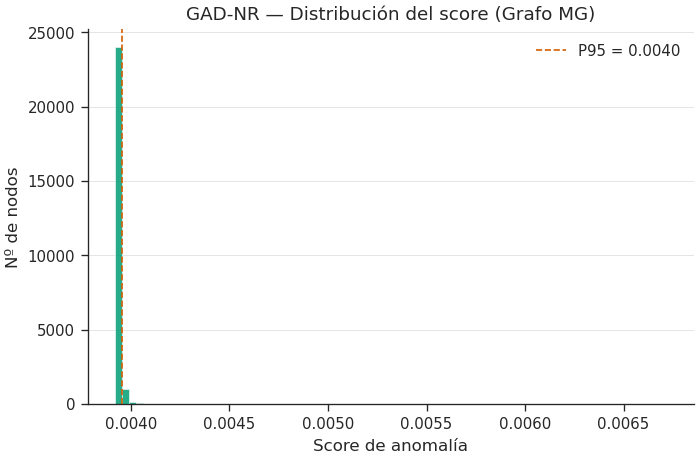

In [12]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo MG)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '07_gadnr_score_distribution_MG.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_score_distributions_MG.png


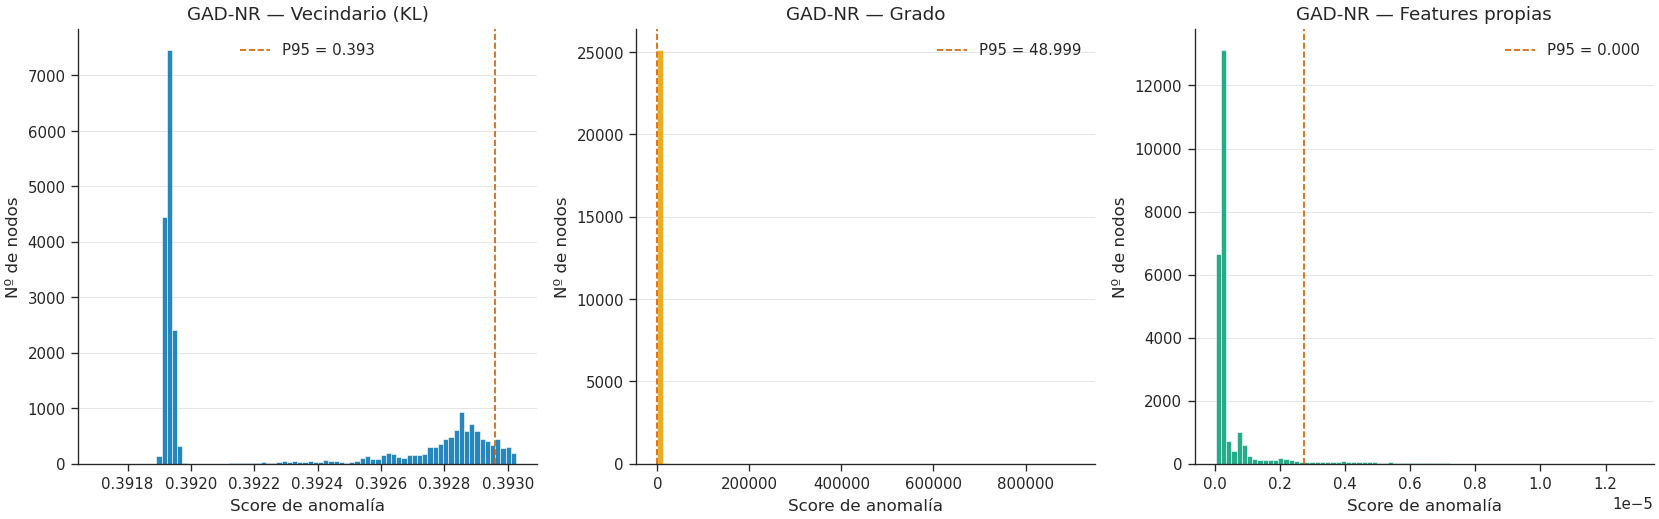

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = 0.1775
  Vecindario vs Features: ρ = -0.1961
  Grado      vs Features: ρ = 0.6703


In [13]:
# Distribución de los sub-scores de GAD-NR
scores_info = [
    (gadnr_h,    'Vecindario (KL)',  CAT_COLORS[0]),
    (gadnr_deg,  'Grado',            CAT_COLORS[1]),
    (gadnr_feat, 'Features propias', CAT_COLORS[2]),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])
for ax, (scores, label, color) in zip(axes, scores_info):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_gadnr_score_distributions_MG.png')
plt.show()

rho_h_deg,    _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,   _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat, _ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')


### 4.1 Comportamiento del curriculum en el grafo MG

Sección a completar tras la ejecución. Comparar los lambdas finales con los de M y G
(0.01/7.6/2.4·10⁻⁵) para verificar si el curriculum sigue siendo invariante al grafo.
Documentar el estado de cada sub-score (operativo / degenerado) y las consecuencias
metodológicas para el resto del análisis.


## 5. Comparativa por tipo de señal

Misma estructura que en los notebooks 05 y 06: cinco señales independientes, umbral P95,
percentiles para comparación entre señales y modelos.

**Nota sobre el umbral K en los solapamientos.** Con 25.233 nodos, top-100 representa el
0.4% del grafo — similar al 0.88% de M. Se mantiene K=100 para coherencia con el grafo M.


In [67]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']   = dom_struct
scores_df['dom_attr']     = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']      = gadnr_h
scores_df['gadnr_deg']    = gadnr_deg
scores_df['gadnr_feat']   = gadnr_feat
scores_df['gadnr_score']  = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95
K = 500

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (25233, 22)
Columnas: ['node_id', 'raw_id', 'idx', 'node_type', 'name', 'city', 'state', 'category_name', 'num_members', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

Sección a completar tras la ejecución.

In [68]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

top_dom_struct = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg  = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')
print(f'Exclusivos DOMINANT-struct : {K - overlap_struct}')
print(f'Exclusivos GAD-NR-deg      : {K - overlap_struct}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.8473
Solapamiento top-500: 494/500 nodos comunes (99%)
Exclusivos DOMINANT-struct : 6
Exclusivos GAD-NR-deg      : 6


In [69]:
# Solapamiento por umbral P95 y Jaccard
ambos_p95  = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_struct'] <  P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'Outliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')


Outliers P95 detectados por ambos : 1223 (97% de la unión)
Solo DOMINANT                      : 39 (3%)
Solo GAD-NR                        : 0 (0%)
Jaccard P95                        : 0.969


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_structural_comparison_MG.png


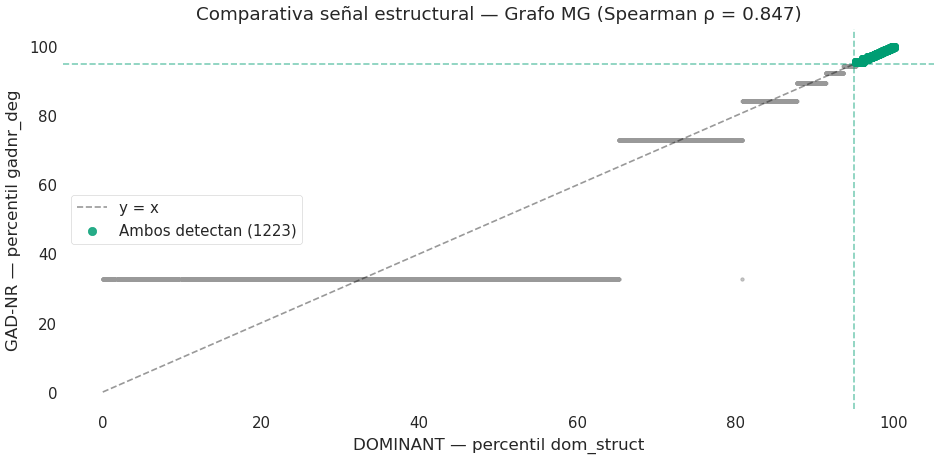

In [70]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=4, alpha=0.15, color=PALETTE['neutral'], zorder=1
)
ax.axvline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=25, alpha=0.85, color=PALETTE['MG'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural — Grafo MG (Spearman ρ = {rho_struct:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True)
ax.tick_params(labelsize=FONT['tick'], length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_structural_comparison_MG.png')
plt.show()


### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

Sección a completar tras la ejecución.

In [71]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

top_dom_attr   = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr   = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')
print(f'Exclusivos DOMINANT-attr : {K - overlap_attr}')
print(f'Exclusivos GAD-NR-feat   : {K - overlap_attr}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = 0.1333
Solapamiento top-500: 44/500 nodos comunes (9%)
Exclusivos DOMINANT-attr : 456
Exclusivos GAD-NR-feat   : 456


In [72]:
# Solapamiento por umbral P95 y Jaccard — atributo
ambos_p95  = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_attr']   <  P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'Outliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')


Outliers P95 detectados por ambos : 490 (24% de la unión)
Solo DOMINANT                      : 772 (38%)
Solo GAD-NR                        : 772 (38%)
Jaccard P95                        : 0.241


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_attribute_comparison_MG.png


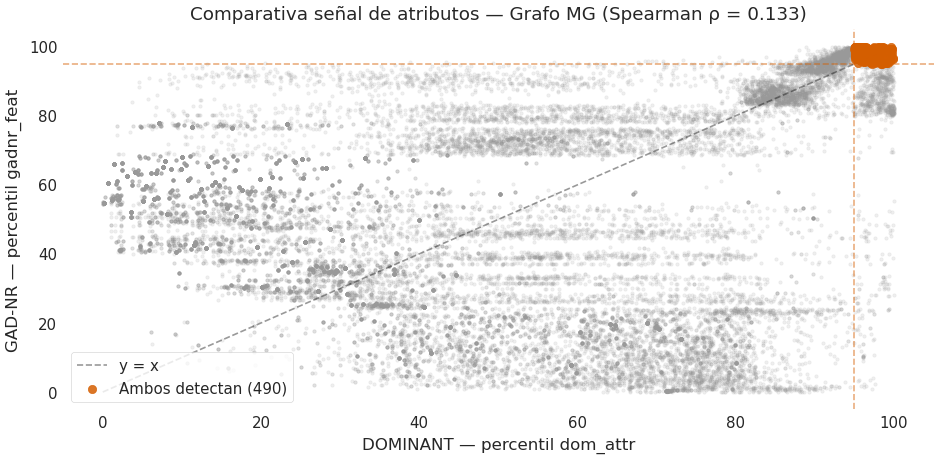

In [73]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=4, alpha=0.15, color=PALETTE['neutral'], zorder=1
)
ax.axvline(P_THRESH, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=25, alpha=0.85, color=PALETTE['anomaly'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos — Grafo MG (Spearman ρ = {rho_attr:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True)
ax.tick_params(labelsize=FONT['tick'], length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_attribute_comparison_MG.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Scatter estructural vs atributo coloreado por tipología asignada. En el grafo MG los
scatters incluyen tanto miembros como grupos — se verifica si los dos tipos de nodo
se separan visualmente en el espacio de percentiles.


In [77]:
# Asignación de tipología
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:6d} ({c/len(scores_df):.1%})')

print('\n=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:6d} ({c/len(scores_df):.1%})')

# Desglose por tipo de nodo
print('\n=== Tipología DOMINANT — por tipo de nodo ===')
print(pd.crosstab(scores_df['node_type'], scores_df['type_dom']))
print('\n=== Tipología GAD-NR — por tipo de nodo ===')
print(pd.crosstab(scores_df['node_type'], scores_df['type_gadnr']))


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         :  23242 (92.1%)
  Atributo       :    729 (2.9%)
  Estructural    :    729 (2.9%)
  Mixta          :    533 (2.1%)

=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         :  23312 (92.4%)
  Atributo       :    698 (2.8%)
  Estructural    :    659 (2.6%)
  Mixta          :    564 (2.2%)

=== Tipología DOMINANT — por tipo de nodo ===
type_dom   Atributo  Estructural  Mixta  Normal
node_type                                      
group           121           53    421       7
member          608          676    112   23235

=== Tipología GAD-NR — por tipo de nodo ===
type_gadnr  Atributo  Estructural  Mixta  Normal
node_type                                       
group             98          155    306      43
member           600          504    258   23269


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_typology_dominant_MG.png


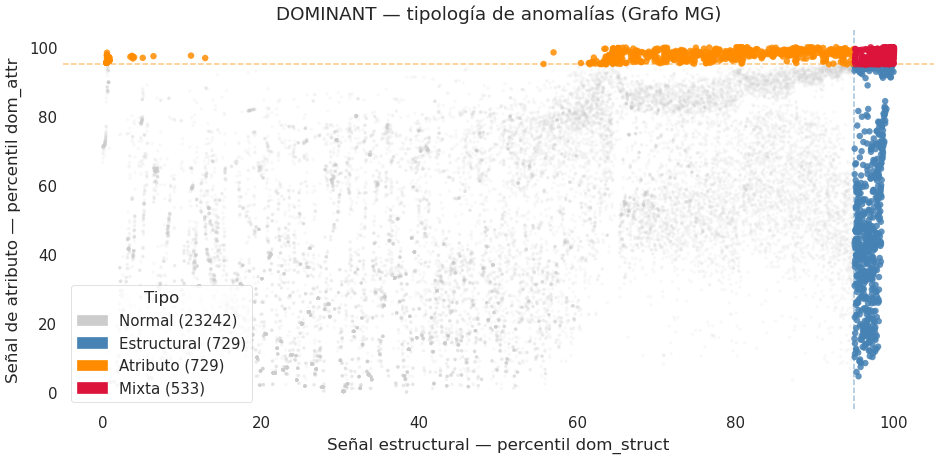

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_typology_gadnr_MG.png


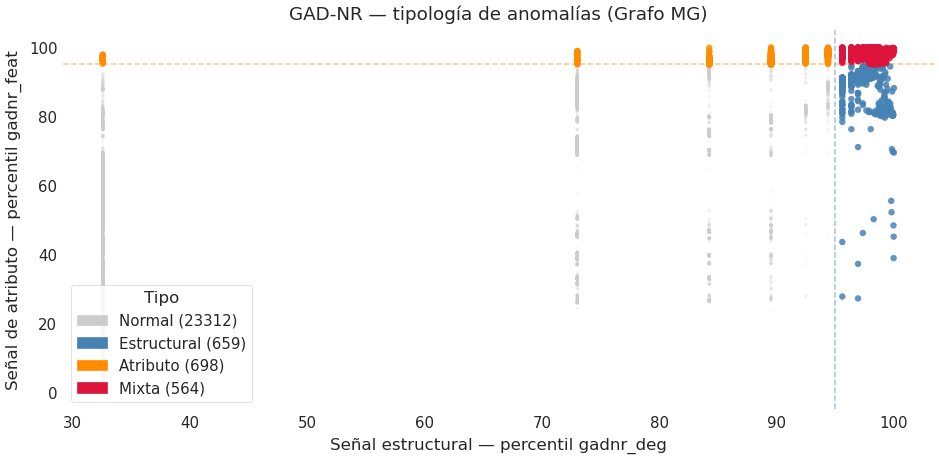

In [22]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#cccccc', 'Estructural': 'steelblue',
              'Atributo': 'darkorange', 'Mixta': 'crimson'}

def plot_typology_scatter(ax, type_col, xcol, ycol, title, xlabel, ylabel):
    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 15 if atype != 'Normal' else 4
        alpha  = 0.85 if atype != 'Normal' else 0.12
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=f'{atype} ({len(group)})', zorder=zorder,
                   edgecolors='none')

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--',
               linewidth=0.9, alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--',
               linewidth=0.9, alpha=0.5)

    legend_patches = [mpatches.Patch(color=color_map[t],
                                     label=f"{t} ({(scores_df[type_col]==t).sum()})")
                      for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo',
              title_fontsize=FONT['legend'] + 1,
              fontsize=FONT['legend'],
              frameon=True, facecolor='white', framealpha=0.85,
              edgecolor='#CCCCCC', loc='lower left')
    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['title'])
    ax.tick_params(labelsize=FONT['tick'], length=0)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(ax, 'type_dom', 'pct_dom_struct', 'pct_dom_attr',
    'DOMINANT — tipología de anomalías (Grafo MG)',
    'Señal estructural — percentil dom_struct',
    'Señal de atributo — percentil dom_attr')
plt.tight_layout()
save_figure(fig, '07_typology_dominant_MG.png')
plt.show()

fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(ax, 'type_gadnr', 'pct_gadnr_deg', 'pct_gadnr_feat',
    'GAD-NR — tipología de anomalías (Grafo MG)',
    'Señal estructural — percentil gadnr_deg',
    'Señal de atributo — percentil gadnr_feat')
plt.tight_layout()
save_figure(fig, '07_typology_gadnr_MG.png')
plt.show()


### 5.4 Distribución del score compuesto

Sección a completar tras la ejecución.

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_composite_score_distributions_MG.png


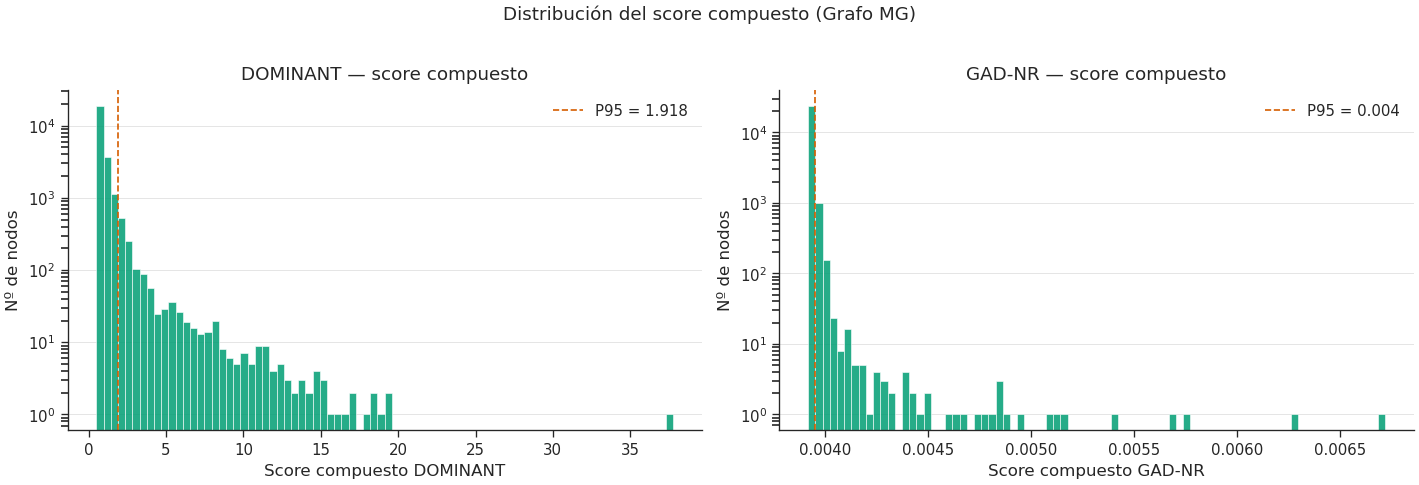

=== Score compuesto — DOMINANT ===
count    25233.000000
mean         0.884343
std          0.982115
min          0.493647
25%          0.514798
50%          0.580693
75%          0.947258
max         37.755795

=== Score compuesto — GAD-NR ===
count    25233.000000
mean         0.003930
std          0.000041
min          0.003920
25%          0.003921
50%          0.003922
75%          0.003931
max          0.006716

Correlación Spearman dom_combined vs gadnr_score: ρ = 0.5913
Solapamiento top-100: 71/100 (71%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

ax = axes[0]
ax.hist(scores_df['dom_combined'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(scores_df['dom_combined'], 95)
ax.axvline(p95_dom, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.3f}')
ax.set_xlabel('Score compuesto DOMINANT', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — score compuesto', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
polish(ax)

ax = axes[1]
ax.hist(scores_df['gadnr_score'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gad = np.percentile(scores_df['gadnr_score'], 95)
ax.axvline(p95_gad, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gad:.3f}')
ax.set_xlabel('Score compuesto GAD-NR', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — score compuesto', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
polish(ax)

plt.suptitle('Distribución del score compuesto (Grafo MG)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_composite_score_distributions_MG.png')
plt.show()

print('=== Score compuesto — DOMINANT ===')
print(scores_df['dom_combined'].describe().to_string())
print('\n=== Score compuesto — GAD-NR ===')
print(scores_df['gadnr_score'].describe().to_string())

rho_comp, _ = spearmanr(scores_df['dom_combined'], scores_df['gadnr_score'])
print(f'\nCorrelación Spearman dom_combined vs gadnr_score: ρ = {rho_comp:.4f}')

top_dom = set(np.argsort(-scores_df['dom_combined'].values)[:K])
top_gad = set(np.argsort(-scores_df['gadnr_score'].values)[:K])
print(f'Solapamiento top-{K}: {len(top_dom & top_gad)}/{K} ({len(top_dom & top_gad)/K:.0%})')


### 5.5 Señal joint-type de GAD-NR

Análisis de `gadnr_h` — la señal joint-type de GAD-NR. En el grafo MG esta señal tiene
una interpretación especial: un miembro con KL alta tiene features que no encajan con las
features de los grupos a los que pertenece, y un grupo con KL alta tiene features que no
encajan con las features de sus miembros. En ambos casos es una señal de incoherencia
entre el nodo y su vecindario.


In [24]:
# Joint-type puros — alto gadnr_h sin anomalía en DOMINANT
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Nodos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  - Miembros: {(pure_joint.node_type == "member").sum()}')
print(f'  - Grupos  : {(pure_joint.node_type == "group").sum()}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'node_type', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Nodos joint-type puros (invisibles para DOMINANT): 1258
  - Miembros: 1258
  - Grupos  : 0
  Grado medio: 0.1 (vs 1.4 global)

Top-10 por gadnr_h:
             name node_type  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
Darlene Valentine    member       0       29.112670     62.053660   100.000000
        Jill Neal    member       0       60.809258     80.719692    99.996037
              Tam    member       0       15.130979     16.426901    99.992074
          Siobhan    member       0       14.873380     14.538501    99.988111
  Richard Binkley    member       0       14.881306     14.538501    99.980185
          Brandon    member       0       14.873380     14.538501    99.980185
         David. G    member       0       14.873380     14.538501    99.980185
 Greg Farricielli    member       0       42.392898     68.992985    99.972259
         A.w. Fug    member       0       35.847898     63.819205    99.966314
              Z W    member       0       35.847898     63.8192

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_joint_type_MG.png


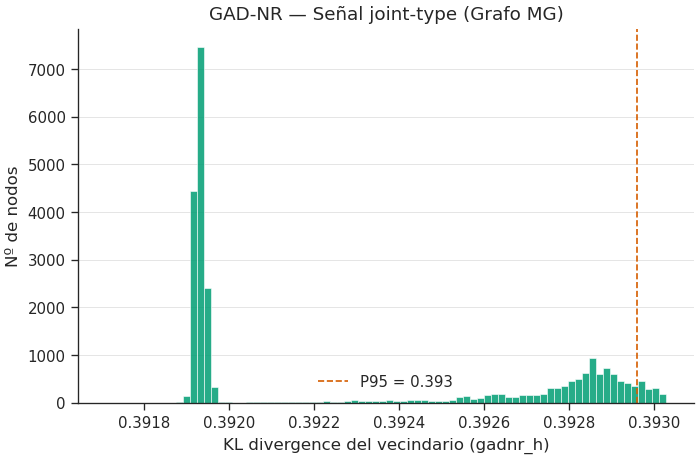

In [25]:
fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(scores_df['gadnr_h'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')
ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo MG)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '07_gadnr_joint_type_MG.png')
plt.show()


## 6. Spotlight — candidatos individuales del EDA

Revisamos los candidatos más relevantes identificados en el EDA del grafo MG con las
cinco señales de los modelos. Los candidatos incluyen tanto miembros como grupos.

**Candidatos miembro:**
- Shalini — 42 grupos, mayor betweenness del grafo M
- Becki Baumgartner — 513 eventos, perfil fiel extremo
- Taylor Michael Matson — 201 eventos en 32 grupos, perfil explorador extremo

**Candidatos grupo:**
- Nashville Social Crew — ratio de actividad 0.07% (grupo fantasma extremo)
- Nashville Hiking Meetup — 15.838 miembros registrados, 878 activos
- 20s in Nashville — grupo más activo en el bipartito (951 miembros activos)


In [26]:
def spotlight_mg(name_fragment, df, label=None, node_type_filter=None):
    mask = df['name'].str.contains(name_fragment, case=False, na=False)
    if node_type_filter:
        mask = mask & (df['node_type'] == node_type_filter)
    matches = df[mask]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    tipo = row['node_type'].upper()
    print(f'  ► [{tipo}] {tag}')
    print(f'    Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):6d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):6d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):6d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):6d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):6d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '\n')

print('--- MIEMBROS ---')
spotlight_mg('Shalini',         scores_df, 'Shalini (42 grupos, mayor betweenness en M)', 'member')
spotlight_mg('Becki Baumgart',  scores_df, 'Becki Baumgartner (513 eventos, perfil fiel)', 'member')
spotlight_mg('Taylor Michael',  scores_df, 'Taylor Michael Matson (32 grupos, explorador)', 'member')

print('--- GRUPOS ---')
spotlight_mg('Nashville Social Crew', scores_df, 'Nashville Social Crew (ratio actividad 0.07%)', 'group')
spotlight_mg('Nashville Hiking',      scores_df, 'Nashville Hiking Meetup (15.838 miembros registrados)', 'group')
spotlight_mg('20s in Nashville',      scores_df, '20s in Nashville (951 miembros activos)', 'group')


CANDIDATOS DEL EDA — LAS 5 SEÑALES

--- MIEMBROS ---
  ► [MEMBER] Shalini (42 grupos, mayor betweenness en M)
    Grado: 0
    DOMINANT  estructural : # 10415/25233  (58.7p)  
    DOMINANT  atributo    : # 14202/25233  (43.7p)  
    GAD-NR    estructural : #  8775/25233  (32.6p)  
    GAD-NR    atributo    : # 23396/25233  (7.3p)  
    GAD-NR    joint-type  : #  3217/25233  (87.2p)  

  ► [MEMBER] Becki Baumgartner (513 eventos, perfil fiel)
    Grado: 4
    DOMINANT  estructural : #   891/25233  (96.5p) ⚠
    DOMINANT  atributo    : # 14934/25233  (40.8p)  
    GAD-NR    estructural : #   834/25233  (96.4p) ⚠
    GAD-NR    atributo    : #  2394/25233  (90.5p)  
    GAD-NR    joint-type  : # 10491/25233  (58.4p)  

  ► [MEMBER] Taylor Michael Matson (32 grupos, explorador)
    Grado: 16
    DOMINANT  estructural : #   279/25233  (98.9p) ⚠
    DOMINANT  atributo    : #  4596/25233  (81.8p)  
    GAD-NR    estructural : #   266/25233  (98.9p) ⚠
    GAD-NR    atributo    : #  1139/25233  

## 7. Comparativa general

Heatmap de correlación Spearman entre las cinco señales y análisis del acuerdo entre
modelos a nivel de tipología. En el grafo MG el heatmap incluye 25.233 nodos de dos
tipos distintos — las correlaciones pueden estar influidas por la heterogeneidad.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_signal_correlation_MG.png


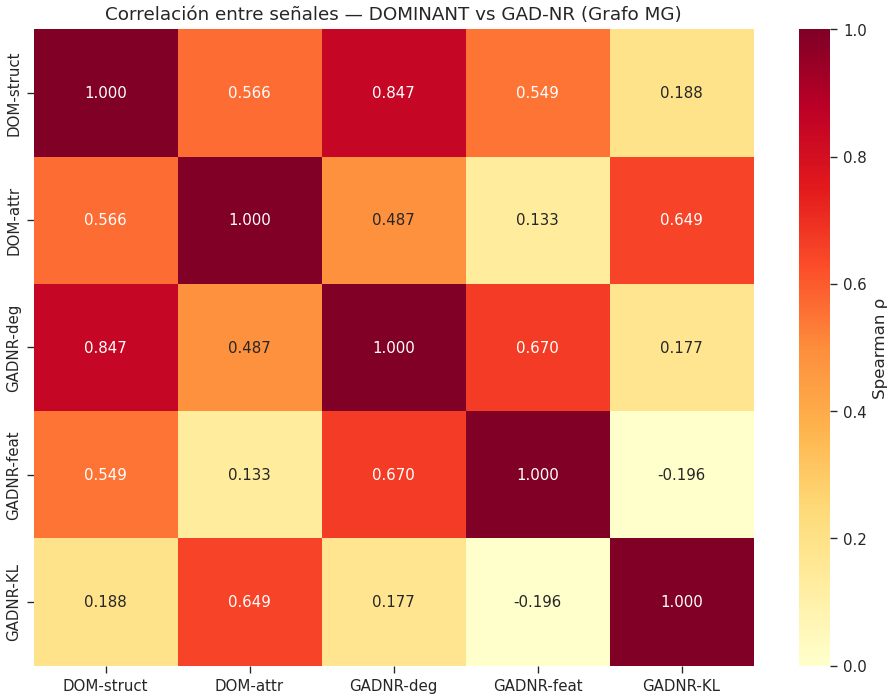

In [27]:
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo MG)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '07_signal_correlation_MG.png')
plt.show()


In [28]:
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Mixta  Normal
DOMINANT                                         
Atributo          116            0      0     613
Estructural         8          508    194      19
Mixta               4          151    370       8
Normal            570            0      0   22672


## 8. Análisis enriquecido del bipartito

Esta sección es exclusiva del grafo MG y aprovecha las características únicas del
grafo bipartito: la distinción entre tipos de nodo, los perfiles de comportamiento
del EDA y la información de actividad real contenida en el peso de las aristas.


### 8.1 Distribución de scores por tipo de nodo

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_scores_by_node_type_MG.png


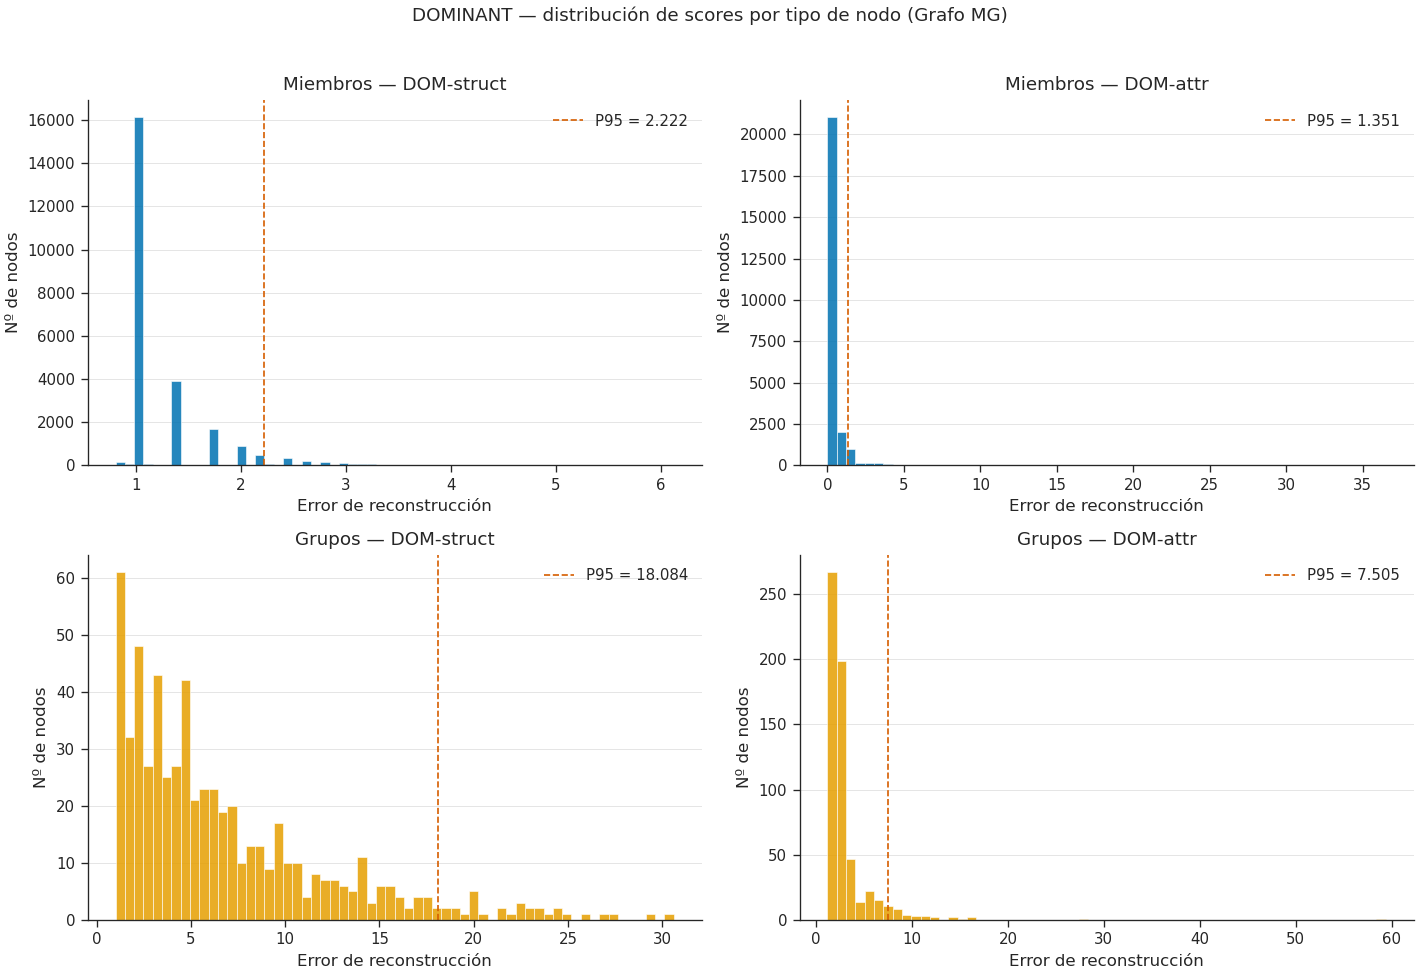


dom_struct:
  Miembros — mean=1.2590, median=0.9988, P95=2.2217
  Grupos   — mean=6.7203, median=4.9078, P95=18.0836

dom_attr:
  Miembros — mean=0.3083, median=0.0822, P95=1.3510
  Grupos   — mean=3.1153, median=2.2583, P95=7.5048


In [48]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.1 DOMINANT — distribución de scores por tipo de nodo
# ═══════════════════════════════════════════════════════════════════════════

# Separar scores por tipo de nodo
members_df = scores_df[scores_df['node_type'] == 'member'].copy()
groups_df  = scores_df[scores_df['node_type'] == 'group'].copy()

fig, axes = plt.subplots(2, 2, figsize=FS['r2c2'])

for row_ax, (df, tipo, color) in zip(axes, [
    (members_df, 'Miembros', PALETTE['M']),
    (groups_df,  'Grupos',   PALETTE['G'])
]):
    for ax, (col, label) in zip(row_ax, [
        ('dom_struct', 'DOM-struct'),
        ('dom_attr',   'DOM-attr')
    ]):
        ax.hist(df[col], bins=60, color=color, edgecolor='white', alpha=0.85)
        p95 = np.percentile(df[col], 95)
        ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
                   label=f'P95 = {p95:.3f}')
        ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
        ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
        ax.set_title(f'{tipo} — {label}', fontsize=FONT['title'])
        ax.legend(fontsize=FONT['legend'], frameon=False)
        polish(ax)

plt.suptitle('DOMINANT — distribución de scores por tipo de nodo (Grafo MG)',
             fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_dominant_scores_by_node_type_MG.png')
plt.show()

for col in ['dom_struct', 'dom_attr']:
    print(f'\n{col}:')
    print(f'  Miembros — mean={members_df[col].mean():.4f}, '
          f'median={members_df[col].median():.4f}, '
          f'P95={np.percentile(members_df[col], 95):.4f}')
    print(f'  Grupos   — mean={groups_df[col].mean():.4f}, '
          f'median={groups_df[col].median():.4f}, '
          f'P95={np.percentile(groups_df[col], 95):.4f}')

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_scores_by_node_type_MG.png


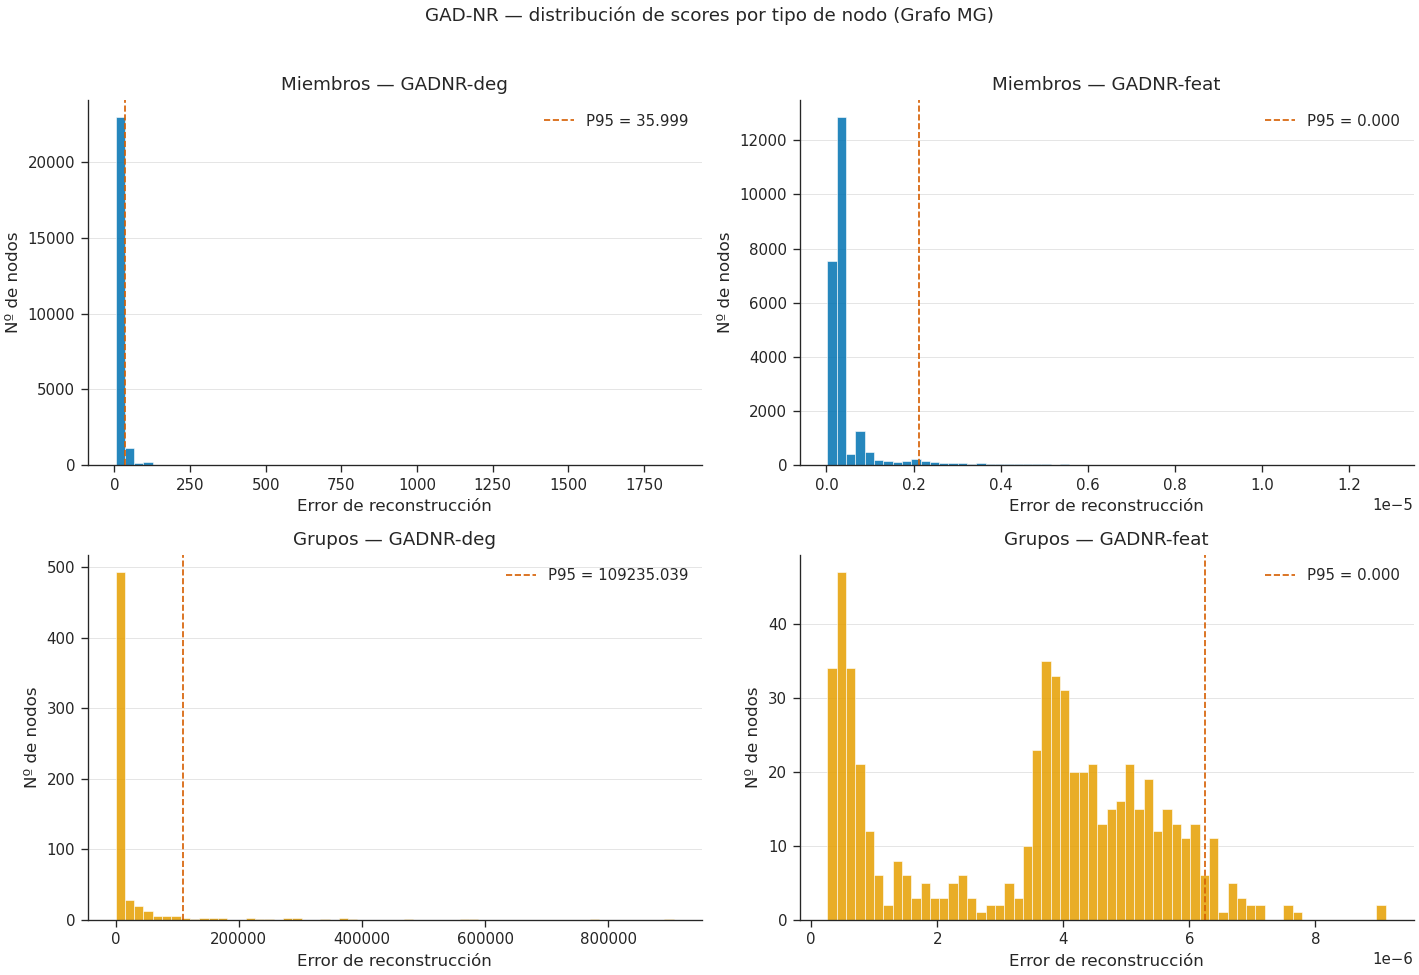


gadnr_deg:
  Miembros — mean=11.9182, median=3.9998, P95=35.9994
  Grupos   — mean=22328.7500, median=624.9975, P95=109235.0391

gadnr_feat:
  Miembros — mean=0.0000, median=0.0000, P95=0.0000
  Grupos   — mean=0.0000, median=0.0000, P95=0.0000


In [47]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.1 GAD-NR — distribución de scores por tipo de nodo
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=FS['r2c2'])

for row_ax, (df, tipo, color) in zip(axes, [
    (members_df, 'Miembros', PALETTE['M']),
    (groups_df,  'Grupos',   PALETTE['G'])
]):
    for ax, (col, label) in zip(row_ax, [
        ('gadnr_deg',  'GADNR-deg'),
        ('gadnr_feat', 'GADNR-feat')
    ]):
        ax.hist(df[col], bins=60, color=color, edgecolor='white', alpha=0.85)
        p95 = np.percentile(df[col], 95)
        ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
                   label=f'P95 = {p95:.3f}')
        ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
        ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
        ax.set_title(f'{tipo} — {label}', fontsize=FONT['title'])
        ax.legend(fontsize=FONT['legend'], frameon=False)
        polish(ax)

plt.suptitle('GAD-NR — distribución de scores por tipo de nodo (Grafo MG)',
             fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_gadnr_scores_by_node_type_MG.png')
plt.show()

for col in ['gadnr_deg', 'gadnr_feat']:
    print(f'\n{col}:')
    print(f'  Miembros — mean={members_df[col].mean():.4f}, '
          f'median={members_df[col].median():.4f}, '
          f'P95={np.percentile(members_df[col], 95):.4f}')
    print(f'  Grupos   — mean={groups_df[col].mean():.4f}, '
          f'median={groups_df[col].median():.4f}, '
          f'P95={np.percentile(groups_df[col], 95):.4f}')

### 8.2 Cruce con perfiles de comportamiento de miembros

In [30]:
# Construir perfiles de comportamiento para los miembros del bipartito
# Basado en el EDA del grafo MG: total_events y num_groups por miembro

# Agregar información de actividad desde mg_edges
member_activity = mg_edges.groupby('member_id').agg(
    total_events=('weight', 'sum'),
    num_groups=('group_id', 'count'),
    mean_events_per_group=('weight', 'mean')
).reset_index()

# Definición de perfiles (del EDA)
def assign_profile(row):
    if row['total_events'] <= 1:
        return 'Inactivo'
    elif row['num_groups'] > 10 and row['mean_events_per_group'] < 3:
        return 'Explorador'
    elif row['num_groups'] <= 3 and row['mean_events_per_group'] > 30:
        return 'Fiel'
    elif row['total_events'] > 100:
        return 'Hiperactivo'
    else:
        return 'Normal'

member_activity['perfil'] = member_activity.apply(assign_profile, axis=1)

print('Distribución de perfiles:')
print(member_activity['perfil'].value_counts())

# Merge con scores_df para miembros
members_scores = members_df.merge(
    member_activity[['member_id', 'total_events', 'num_groups',
                     'mean_events_per_group', 'perfil']],
    left_on='raw_id', right_on='member_id', how='left'
)
members_scores['perfil'] = members_scores['perfil'].fillna('Normal')

print(f'\nMiembros con perfil asignado: {members_scores["perfil"].notna().sum()}')


Distribución de perfiles:
perfil
Normal         13444
Inactivo       10834
Fiel             177
Explorador       151
Hiperactivo       25
Name: count, dtype: int64

Miembros con perfil asignado: 24631


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_hist_profiles_MG.png


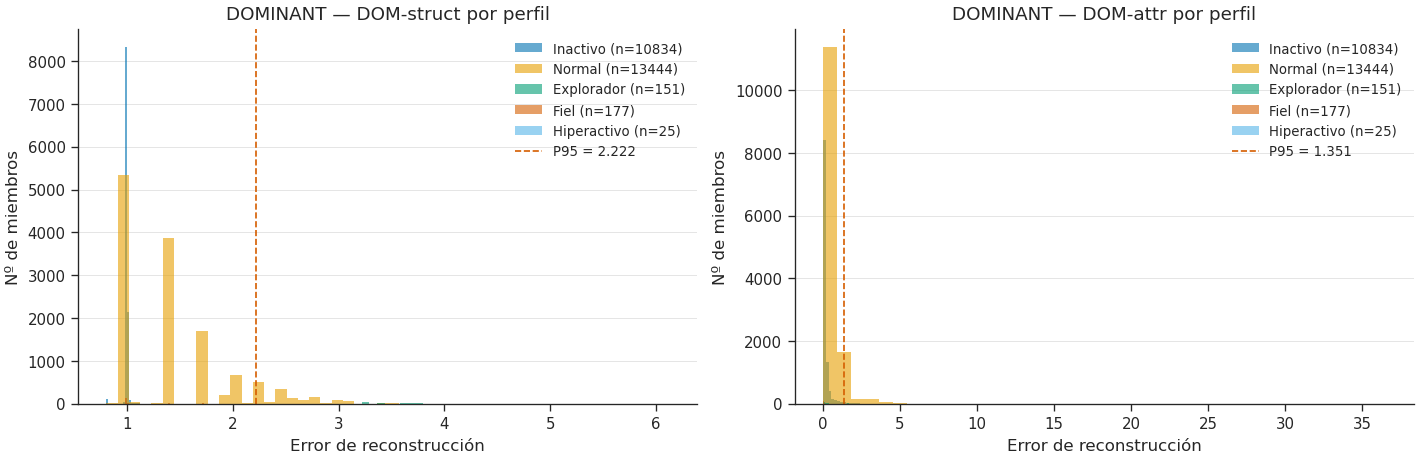

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_boxplot_profiles_MG.png


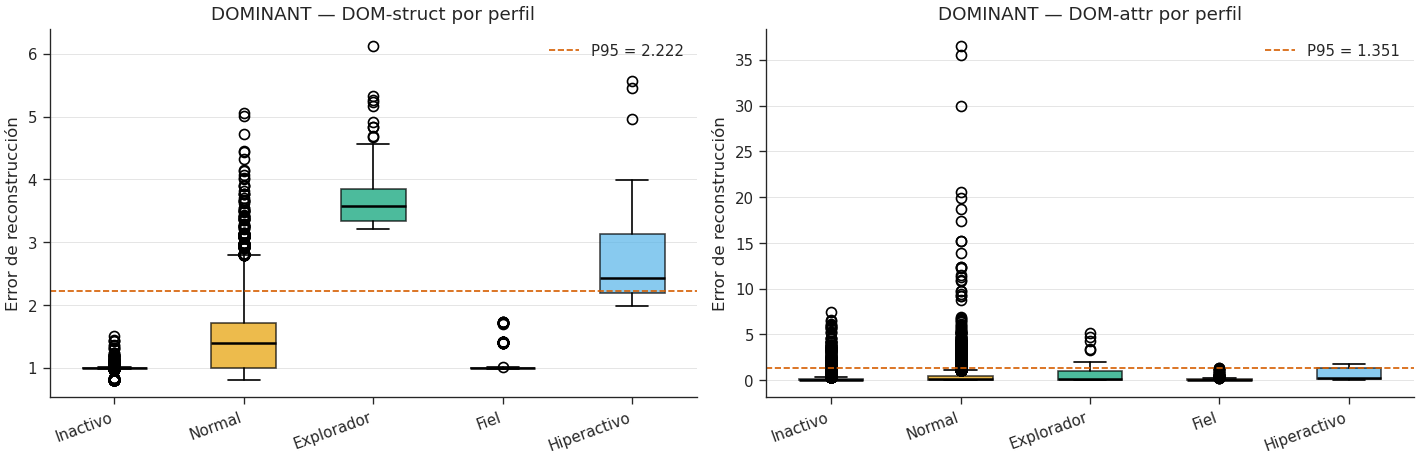

In [49]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2 DOMINANT — perfiles de comportamiento
# ═══════════════════════════════════════════════════════════════════════════
perfil_order  = ['Inactivo', 'Normal', 'Explorador', 'Fiel', 'Hiperactivo']
perfil_colors = {p: CAT_COLORS[i] for i, p in enumerate(perfil_order)}

fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    for perfil in perfil_order:
        subset = members_scores[members_scores['perfil'] == perfil][col]
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=40, alpha=0.6,
                label=f'{perfil} (n={len(subset)})',
                color=perfil_colors[perfil], edgecolor='none')
    p95 = np.percentile(members_scores[col], 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de miembros', fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'] - 1, frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_dominant_hist_profiles_MG.png')
plt.show()

# Boxplot DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    data_by_perfil = [members_scores[members_scores['perfil'] == p][col].values
                      for p in perfil_order]
    bp = ax.boxplot(data_by_perfil, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, perfil in zip(bp['boxes'], perfil_order):
        patch.set_facecolor(perfil_colors[perfil])
        patch.set_alpha(0.7)
    p95 = np.percentile(members_scores[col], 95)
    ax.axhline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xticklabels(perfil_order, rotation=20, ha='right',
                       fontsize=FONT['tick'])
    ax.set_ylabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_dominant_boxplot_profiles_MG.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_hist_profiles_MG.png


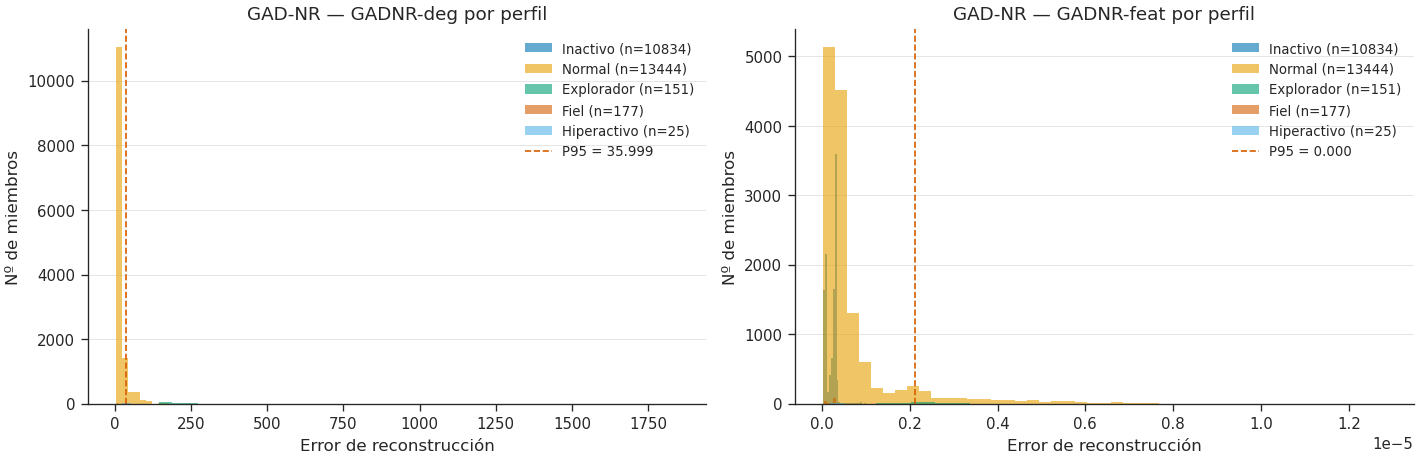

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_boxplot_profiles_MG.png


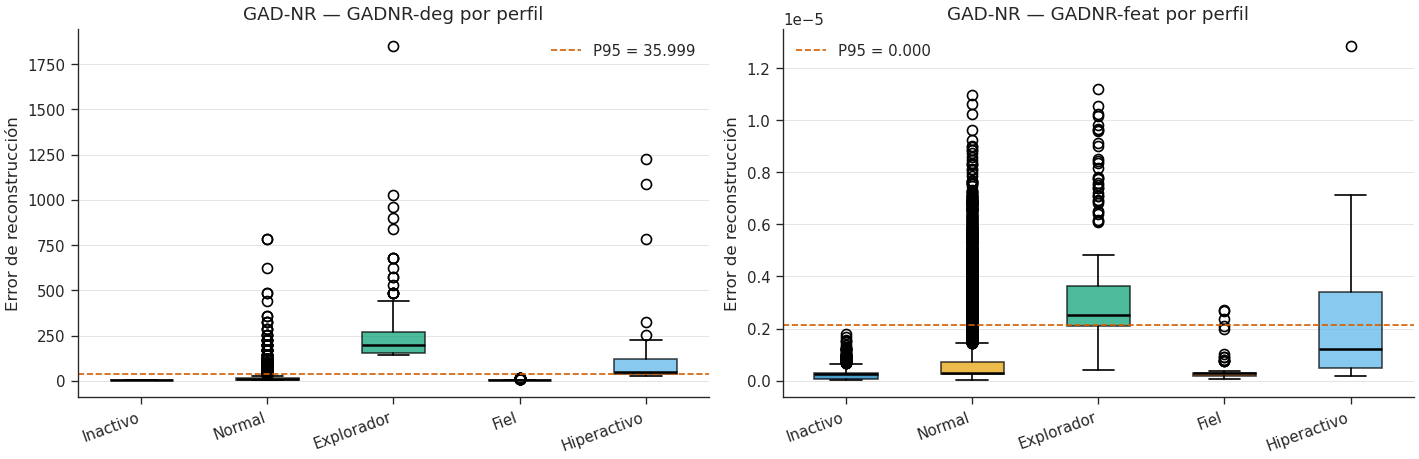

In [51]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2 GAD-NR — perfiles de comportamiento
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat']):
    for perfil in perfil_order:
        subset = members_scores[members_scores['perfil'] == perfil][col]
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=40, alpha=0.6,
                label=f'{perfil} (n={len(subset)})',
                color=perfil_colors[perfil], edgecolor='none')
    p95 = np.percentile(members_scores[col], 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de miembros', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'] - 1, frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_gadnr_hist_profiles_MG.png')
plt.show()

# Boxplot GAD-NR
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat']):
    data_by_perfil = [members_scores[members_scores['perfil'] == p][col].values
                      for p in perfil_order]
    bp = ax.boxplot(data_by_perfil, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, perfil in zip(bp['boxes'], perfil_order):
        patch.set_facecolor(perfil_colors[perfil])
        patch.set_alpha(0.7)
    p95 = np.percentile(members_scores[col], 95)
    ax.axhline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xticklabels(perfil_order, rotation=20, ha='right',
                       fontsize=FONT['tick'])
    ax.set_ylabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_gadnr_boxplot_profiles_MG.png')
plt.show()

In [50]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2 Tabla estadísticos por perfil — cinco señales
# ═══════════════════════════════════════════════════════════════════════════
score_cols_members = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']

for col in score_cols_members:
    p95_global = np.percentile(members_scores[col], 95)
    print(f'\n=== {col} — frac_P95 por perfil ===')
    print(members_scores.groupby('perfil')[col].agg(
        mean='mean',
        median='median',
        std='std',
        frac_P95=lambda x: (x >= p95_global).mean()
    ).round(4).to_string())


=== dom_struct — frac_P95 por perfil ===
               mean  median     std  frac_P95
perfil                                       
Explorador   3.7084  3.5696  0.5180    1.0000
Fiel         1.0886  0.9963  0.2095    0.0000
Hiperactivo  2.9181  2.4358  1.0782    0.5600
Inactivo     0.9953  0.9962  0.0252    0.0000
Normal       1.4431  1.4035  0.5076    0.0794

=== dom_attr — frac_P95 por perfil ===
               mean  median     std  frac_P95
perfil                                       
Explorador   0.6187  0.1680  0.9290    0.2517
Fiel         0.1579  0.0509  0.2744    0.0056
Hiperactivo  0.5759  0.2881  0.6239    0.2000
Inactivo     0.1725  0.0449  0.4213    0.0190
Normal       0.4157  0.1069  0.9664    0.0730

=== gadnr_deg — frac_P95 por perfil ===
                   mean      median         std  frac_P95
perfil                                                   
Explorador   270.124298  195.998596  209.352798    1.0000
Fiel           5.338800    3.999800    3.190500    0.0000
H

### 8.3 Cruce con ratio de actividad de grupos

In [33]:
# Ratio de actividad: miembros activos en bipartito / miembros registrados en meta_groups
active_per_group = mg_edges.groupby('group_id').size().reset_index(name='active_members')
meta_groups_activity = meta_groups[['group_id', 'group_name', 'num_members', 'category_name']].merge(
    active_per_group, on='group_id', how='left'
)
meta_groups_activity['active_members'] = meta_groups_activity['active_members'].fillna(0)
meta_groups_activity['activity_ratio'] = (
    meta_groups_activity['active_members'] / meta_groups_activity['num_members']
)

# Categorías de ratio de actividad
def assign_activity_cat(ratio):
    if ratio < 0.05:  return 'Fantasma (<5%)'
    elif ratio < 0.10: return 'Muy bajo (5-10%)'
    elif ratio < 0.25: return 'Bajo (10-25%)'
    else:              return 'Normal (>25%)'

meta_groups_activity['activity_cat'] = meta_groups_activity['activity_ratio'].apply(assign_activity_cat)

print('Distribución de categorías de actividad:')
print(meta_groups_activity['activity_cat'].value_counts())
print(f'\nGrupos truncados (200 eventos): {(meta_groups_activity.get("num_events", pd.Series()) == 200).sum()}')

# Merge con scores_df para grupos
groups_scores = groups_df.merge(
    meta_groups_activity[['group_id', 'activity_ratio', 'activity_cat', 'active_members']],
    left_on='raw_id', right_on='group_id', how='left'
)

print(f'\nGrupos con ratio asignado: {groups_scores["activity_ratio"].notna().sum()}')


Distribución de categorías de actividad:
activity_cat
Bajo (10-25%)       235
Normal (>25%)       141
Muy bajo (5-10%)    115
Fantasma (<5%)      111
Name: count, dtype: int64

Grupos truncados (200 eventos): 0

Grupos con ratio asignado: 602


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_activity_ratio_MG.png


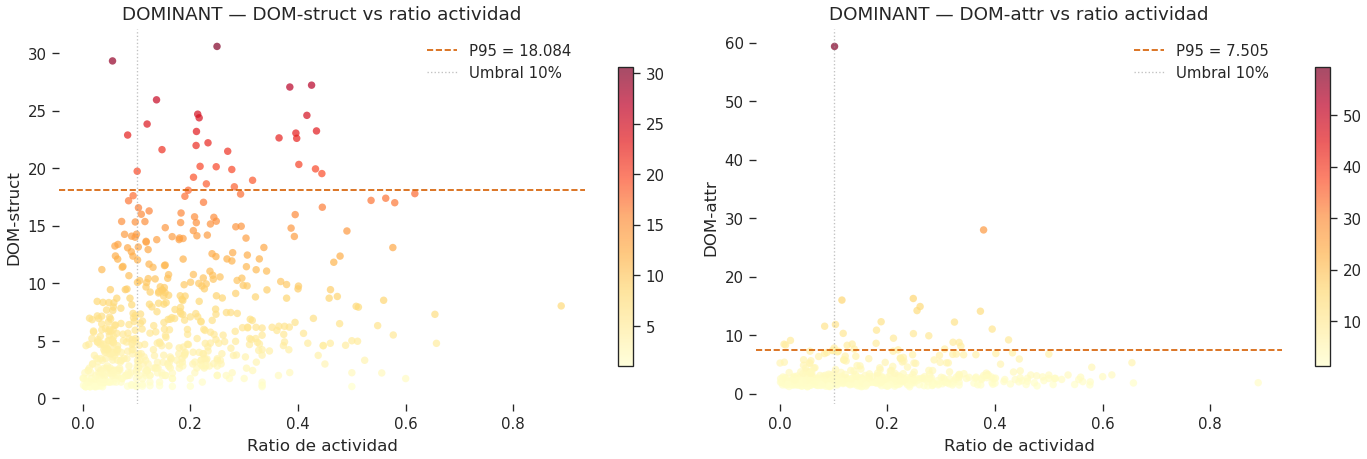

In [52]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3 DOMINANT — ratio de actividad de grupos
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    sc = ax.scatter(
        groups_scores['activity_ratio'],
        groups_scores[col],
        c=groups_scores[col],
        s=20, alpha=0.7, cmap=CMAP_HEAT, edgecolors='none'
    )
    p95 = np.percentile(groups_scores[col], 95)
    ax.axhline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.axvline(0.10, color=PALETTE['neutral'], linestyle=':', linewidth=0.8,
               alpha=0.6, label='Umbral 10%')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel('Ratio de actividad', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} vs ratio actividad', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_dominant_activity_ratio_MG.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_activity_ratio_MG.png


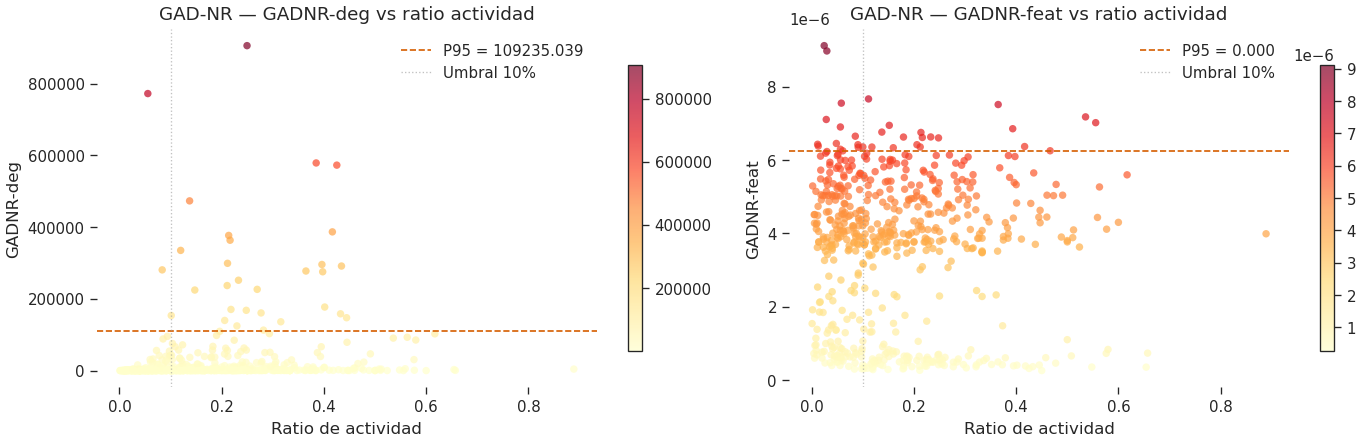

In [54]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3 GAD-NR — ratio de actividad de grupos
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, col, label in zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat']):
    sc = ax.scatter(
        groups_scores['activity_ratio'],
        groups_scores[col],
        c=groups_scores[col],
        s=20, alpha=0.7, cmap=CMAP_HEAT, edgecolors='none'
    )
    p95 = np.percentile(groups_scores[col], 95)
    ax.axhline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.axvline(0.10, color=PALETTE['neutral'], linestyle=':', linewidth=0.8,
               alpha=0.6, label='Umbral 10%')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel('Ratio de actividad', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} vs ratio actividad', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_gadnr_activity_ratio_MG.png')
plt.show()

In [53]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3 Tabla estadísticos por categoría de actividad — cinco señales
# ═══════════════════════════════════════════════════════════════════════════
score_cols_groups = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']

for col in score_cols_groups:
    p95_global = np.percentile(groups_scores[col], 95)
    print(f'\n=== {col} por categoría de actividad ===')
    print(groups_scores.groupby('activity_cat')[col].agg(
        count='count',
        mean='mean',
        median='median',
        frac_P95=lambda x: (x >= p95_global).mean()
    ).round(4).to_string())


=== dom_struct por categoría de actividad ===
                  count    mean  median  frac_P95
activity_cat                                     
Bajo (10-25%)       235  7.5868  5.9989    0.0638
Fantasma (<5%)      111  3.2213  2.4092    0.0000
Muy bajo (5-10%)    115  6.0086  4.6968    0.0174
Normal (>25%)       141  8.6114  6.2743    0.0993

=== dom_attr por categoría de actividad ===
                  count    mean  median  frac_P95
activity_cat                                     
Bajo (10-25%)       235  3.3754  2.3382    0.0638
Fantasma (<5%)      111  2.4095  2.0446    0.0270
Muy bajo (5-10%)    115  2.5558  2.1030    0.0087
Normal (>25%)       141  3.6937  2.6415    0.0851

=== gadnr_deg por categoría de actividad ===
                  count          mean       median  frac_P95
activity_cat                                                
Bajo (10-25%)       235  27112.826172  1368.996338    0.0638
Fantasma (<5%)      111    654.512024    48.999298    0.0000
Muy bajo (5-10%)  

### 8.4 Análisis de pesos de aristas

In [55]:
# El peso de arista en MG = número de eventos asistidos
# Es la única métrica de actividad real del dataset

# Peso medio de aristas por nodo
edge_src_np  = data_MG.edge_index[0].numpy()
edge_dst_np  = data_MG.edge_index[1].numpy()
edge_weights = data_MG.edge_weight.numpy()

# Peso medio por nodo (promedio de los pesos de todas sus aristas)
weight_sum   = np.bincount(edge_src_np, weights=edge_weights, minlength=data_MG.num_nodes)
degree_count = np.bincount(edge_src_np, minlength=data_MG.num_nodes)
mean_weight  = np.where(degree_count > 0, weight_sum / degree_count, 0)

scores_df['mean_edge_weight'] = mean_weight

# Para miembros: peso medio = media de eventos por grupo
# Para grupos: peso medio = media de eventos por miembro activo
print('Peso medio de aristas:')
print(f'  Miembros — mean={mean_weight[:n_members].mean():.2f}, '
      f'median={np.median(mean_weight[:n_members]):.2f}, '
      f'max={mean_weight[:n_members].max():.2f}')
print(f'  Grupos   — mean={mean_weight[n_members:].mean():.2f}, '
      f'median={np.median(mean_weight[n_members:]):.2f}, '
      f'max={mean_weight[n_members:].max():.2f}')


Peso medio de aristas:
  Miembros — mean=2.76, median=1.00, max=200.00
  Grupos   — mean=2.69, median=2.00, max=41.79


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_weight_vs_score_MG.png


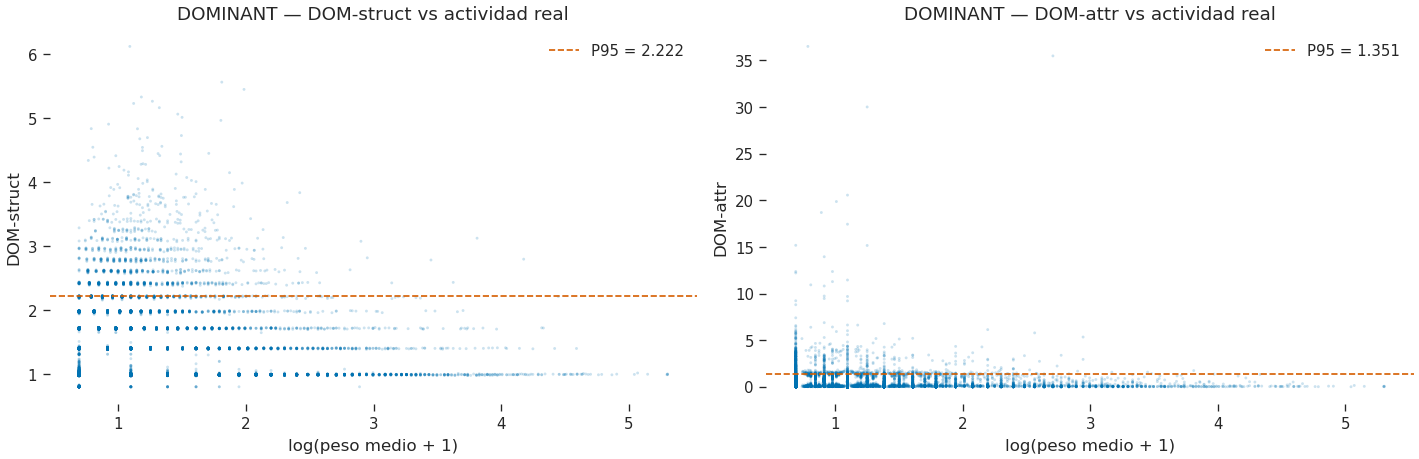

In [58]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4 DOMINANT — peso de aristas vs score
# ═══════════════════════════════════════════════════════════════════════════
member_weights = mean_weight[:n_members]

fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    ax.scatter(np.log1p(member_weights),
               members_df[col],
               s=3, alpha=0.2, color=PALETTE['M'], edgecolors='none')
    p95 = np.percentile(members_df[col], 95)
    ax.axhline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('log(peso medio + 1)', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} vs actividad real', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_dominant_weight_vs_score_MG.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_weight_vs_score_MG.png


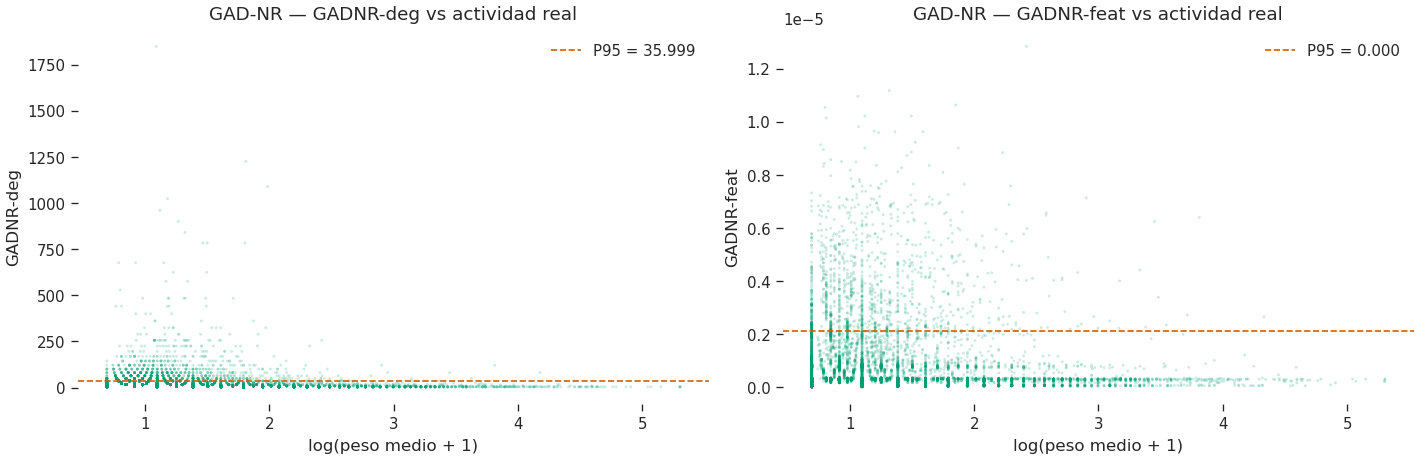

In [59]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4 GAD-NR — peso de aristas vs score
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat']):
    ax.scatter(np.log1p(member_weights),
               members_df[col],
               s=3, alpha=0.2, color=PALETTE['MG'], edgecolors='none')
    p95 = np.percentile(members_df[col], 95)
    ax.axhline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('log(peso medio + 1)', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} vs actividad real', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_gadnr_weight_vs_score_MG.png')
plt.show()

In [57]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4 Correlaciones peso medio vs cinco señales
# ═══════════════════════════════════════════════════════════════════════════
print('Correlación Spearman peso_medio vs señales (miembros):')
for col in ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']:
    rho, _ = spearmanr(member_weights, members_df[col])
    print(f'  {col:<15}: ρ = {rho:.4f}')

Correlación Spearman peso_medio vs señales (miembros):
  dom_struct     : ρ = 0.2050
  dom_attr       : ρ = 0.0822
  gadnr_deg      : ρ = 0.2840
  gadnr_feat     : ρ = 0.1811
  gadnr_h        : ρ = 0.0633


### 8.5 Spotlight por perfil de comportamiento

In [60]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.5 Spotlight por perfil — ordenado por dom_combined
# ═══════════════════════════════════════════════════════════════════════════
cols_show = ['name', 'city', 'degree', 'total_events', 'num_groups',
             'pct_dom_struct', 'pct_dom_attr',
             'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']

print('=' * 70)
print('SPOTLIGHT POR PERFIL — ordenado por dom_combined')
print('=' * 70)
for perfil in perfil_order:
    subset = members_scores[members_scores['perfil'] == perfil]
    if len(subset) == 0:
        continue
    print(f'\n--- {perfil} (n={len(subset)}) ---')
    print(subset.nlargest(3, 'dom_combined')[cols_show].to_string(index=False))

SPOTLIGHT POR PERFIL — ordenado por dom_combined

--- Inactivo (n=10834) ---
           name           city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
    Jon Jonsson  Hafnarfjörður       0             1           1       65.132961     99.782031      32.616019       46.883050    61.578092
        Janetta      Anchorage       0             1           1       65.228074     99.702770      32.616019       80.323386    63.111798
Gustavo Martins Rio de Janeiro       0             1           1       80.830658     99.651250      32.616019       90.238973    58.906987

--- Normal (n=13444) ---
             name       city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
  Taplino Dahmari   Brisbane       2             6           5       92.684183     99.996037      92.474141       27.991123    58.859430
         Adrianne Wellington       1            28           2     

In [64]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.5 Spotlight por perfil — ordenado por gadnr_score
# ═══════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('SPOTLIGHT POR PERFIL — ordenado por gadnr_score')
print('=' * 70)
for perfil in perfil_order:
    subset = members_scores[members_scores['perfil'] == perfil]
    if len(subset) == 0:
        continue
    print(f'\n--- {perfil} (n={len(subset)}) ---')
    print(subset.nlargest(3, 'gadnr_score')[cols_show].to_string(index=False))

SPOTLIGHT POR PERFIL — ordenado por gadnr_score

--- Inactivo (n=10834) ---
       name       city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
Dean Dunfee  La Vergne       0             1           1       65.115127     92.073872      32.616019       92.153133    87.898783
     Amanda   Fairview       0             1           1       65.069552     91.455633      32.616019       91.812309    78.617287
 Pete Rolaf Chesapeake       0             1           1       65.168628     98.787302      32.616019       91.273333    67.205643

--- Normal (n=13444) ---
                name      city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
      Samuel Danache Hermitage       5            19          10       97.467602     95.375104      97.342765       99.992074    87.916617
           Calvin J.   Antioch      12            83          24       98.688226     95.208655  

In [66]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.5 Grupos fantasma — DOMINANT vs GAD-NR
# ═══════════════════════════════════════════════════════════════════════════
cols_groups_show = ['name', 'activity_ratio', 'active_members',
                    'pct_dom_struct', 'pct_dom_attr',
                    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']

fantasma = groups_scores[groups_scores['activity_cat'] == 'Fantasma (<5%)']
print(f'Total grupos fantasma: {len(fantasma)}')

print('\n--- Top-5 por dom_attr ---')
print(fantasma.nlargest(5, 'dom_attr')[cols_groups_show].to_string(index=False))

print('\n--- Top-5 por gadnr_deg ---')
print(fantasma.nlargest(5, 'gadnr_deg')[cols_groups_show].to_string(index=False))

Total grupos fantasma: 111

--- Top-5 por dom_attr ---
                                   name  activity_ratio  active_members  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
        MHO Nashville Active Adventures        0.020047              34       98.977529     99.841477      98.973566       82.071097    59.513336
                Nashville Travel Meetup        0.008108               3       84.583680     99.817699      84.262672       90.135933    60.702255
Nashville Tennis Lessons- PlayYourCourt        0.010989               2       71.315341     99.813736      73.031348       96.365870    59.830381
      Nashville Outdoor Adventures Club        0.044428              59       99.266833     99.623509      99.268815       82.697262    61.082709
     I am Happy Project - Brentwood, TN        0.008658               2       75.979868     99.560100      73.031348       86.446320    61.506757

--- Top-5 por gadnr_deg ---
                                        

## 9. Visualización t-SNE de los embeddings

Proyectamos los embeddings latentes de cada modelo a 2D mediante t-SNE. Con 25.233
puntos el cálculo tarda más que en G (~5-10 minutos por modelo en CPU, ~1-2 en GPU).
Generamos cinco vistas por modelo:

1. **Tipo de nodo** (miembro vs grupo) — verifica si el modelo separa los dos tipos.
2. **Tipo de anomalía** — igual que en M y G.
3. **Score compuesto** — gradiente continuo.
4. **Perfil de comportamiento** — vista exclusiva del bipartito.
5. **Grado del nodo** — igual que en M y G.


In [38]:
@torch.no_grad()
def get_dominant_embeddings(detector, data):
    model = detector.model
    model.eval()
    x          = data.x.to(detector.device)
    edge_index = data.edge_index.to(detector.device)
    z = model.shared_encoder(x, edge_index)
    return z.cpu().numpy()

@torch.no_grad()
def get_gadnr_embeddings(detector, data):
    model = detector.model
    model.eval()
    data.x          = data.x.to(detector.device)
    data.edge_index = data.edge_index.to(detector.device)
    h0, _, _, _ = model(data.x, data.edge_index)
    return h0.cpu().numpy()

emb_dom   = get_dominant_embeddings(dominant, data_MG_clean)
emb_gadnr = get_gadnr_embeddings(gadnr,      data_MG_clean)

print(f'Embeddings DOMINANT : {emb_dom.shape}')
print(f'Embeddings GAD-NR   : {emb_gadnr.shape}')


Embeddings DOMINANT : (25233, 64)
Embeddings GAD-NR   : (25233, 64)


In [39]:
from sklearn.manifold import TSNE

def run_tsne(embeddings, label):
    print(f'Calculando t-SNE sobre embeddings de {label}...')
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)

tsne_dom   = run_tsne(emb_dom,   'DOMINANT')
tsne_gadnr = run_tsne(emb_gadnr, 'GAD-NR')

print(f't-SNE DOMINANT shape: {tsne_dom.shape}')
print(f't-SNE GAD-NR  shape: {tsne_gadnr.shape}')


Calculando t-SNE sobre embeddings de DOMINANT...
Calculando t-SNE sobre embeddings de GAD-NR...
t-SNE DOMINANT shape: (25233, 2)
t-SNE GAD-NR  shape: (25233, 2)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_node_type_MG.png


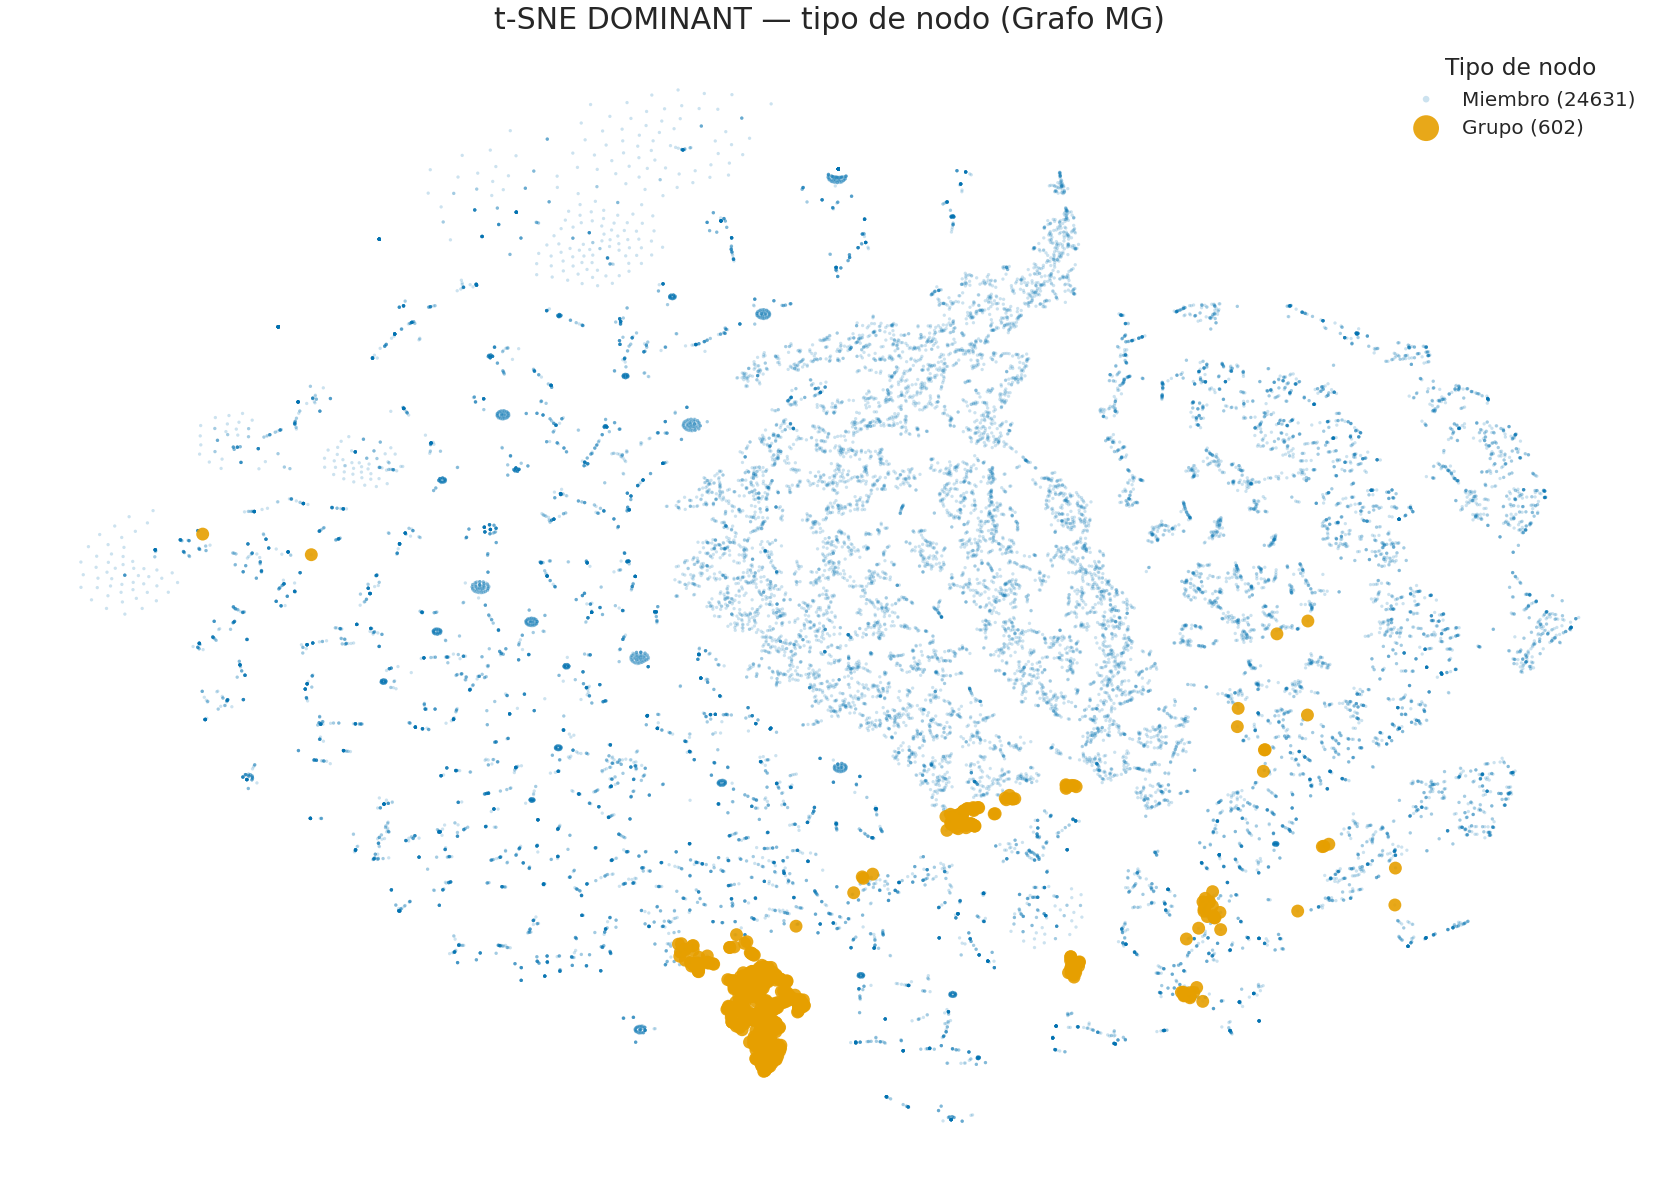

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_type_MG.png


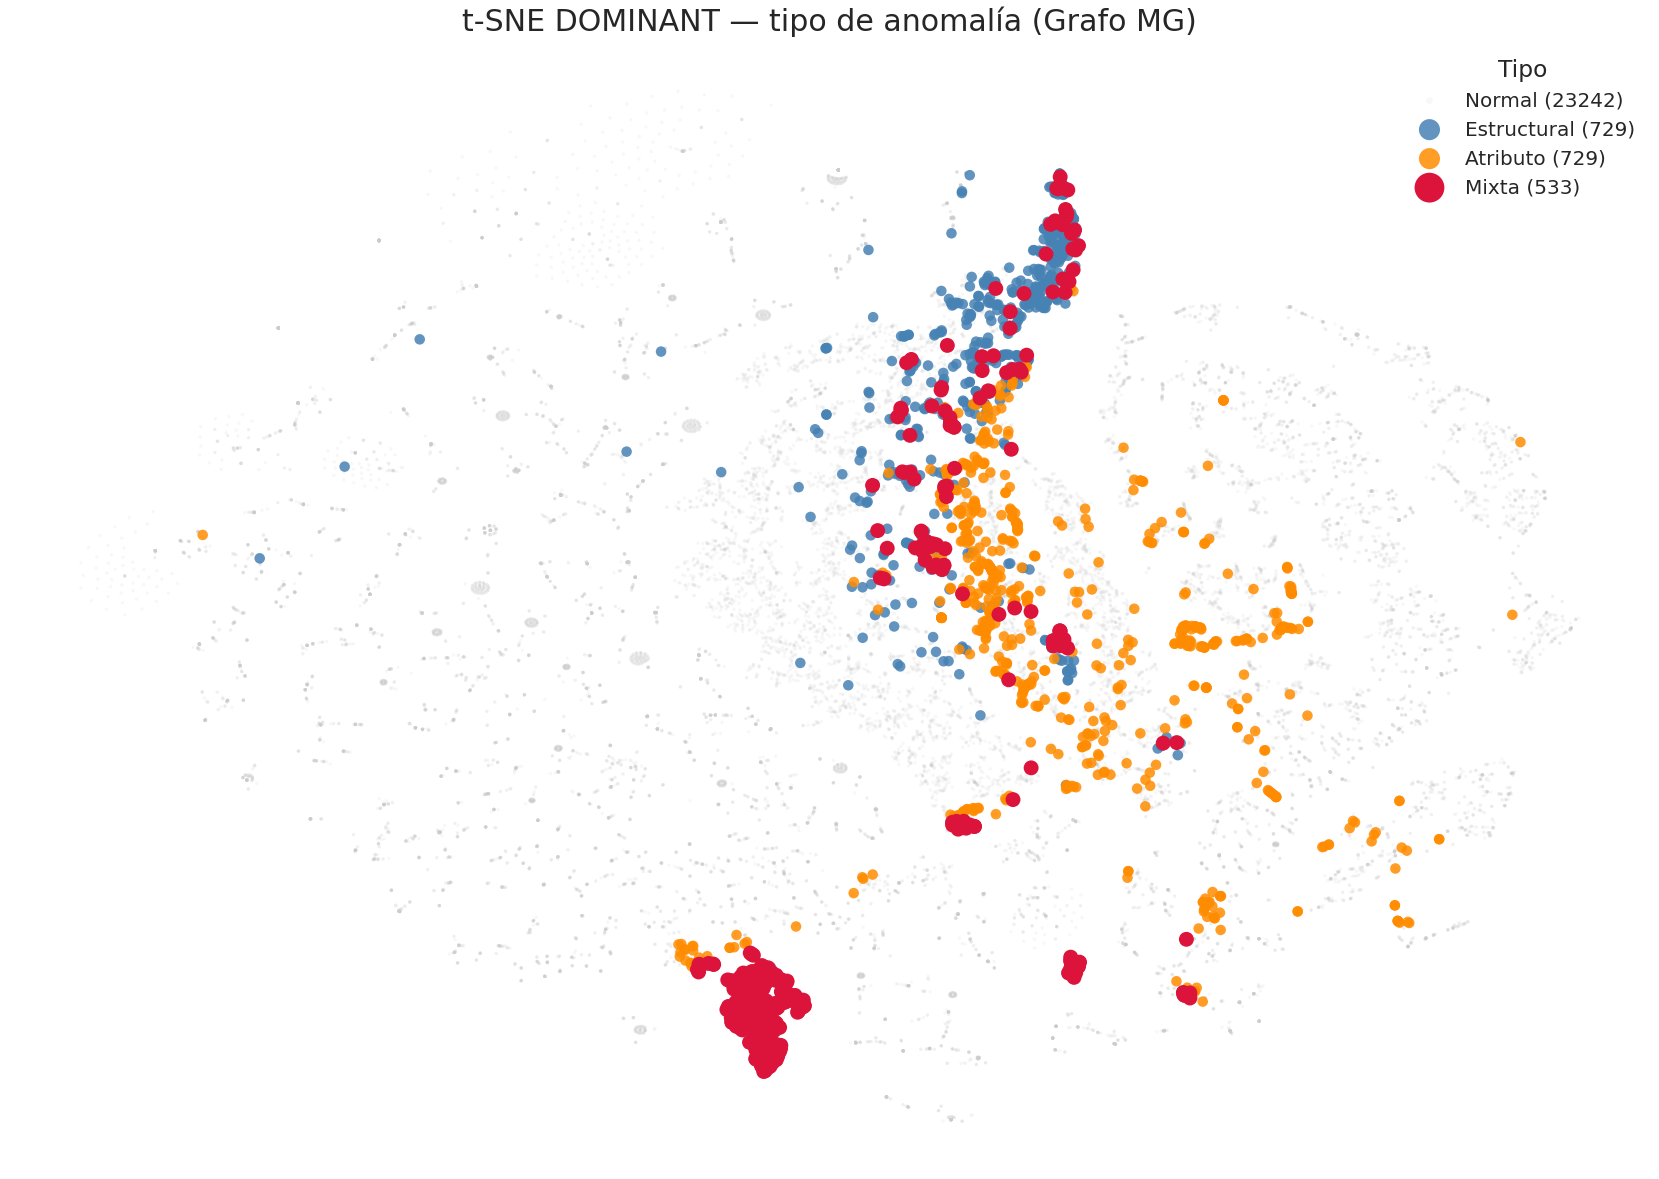

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_score_MG.png


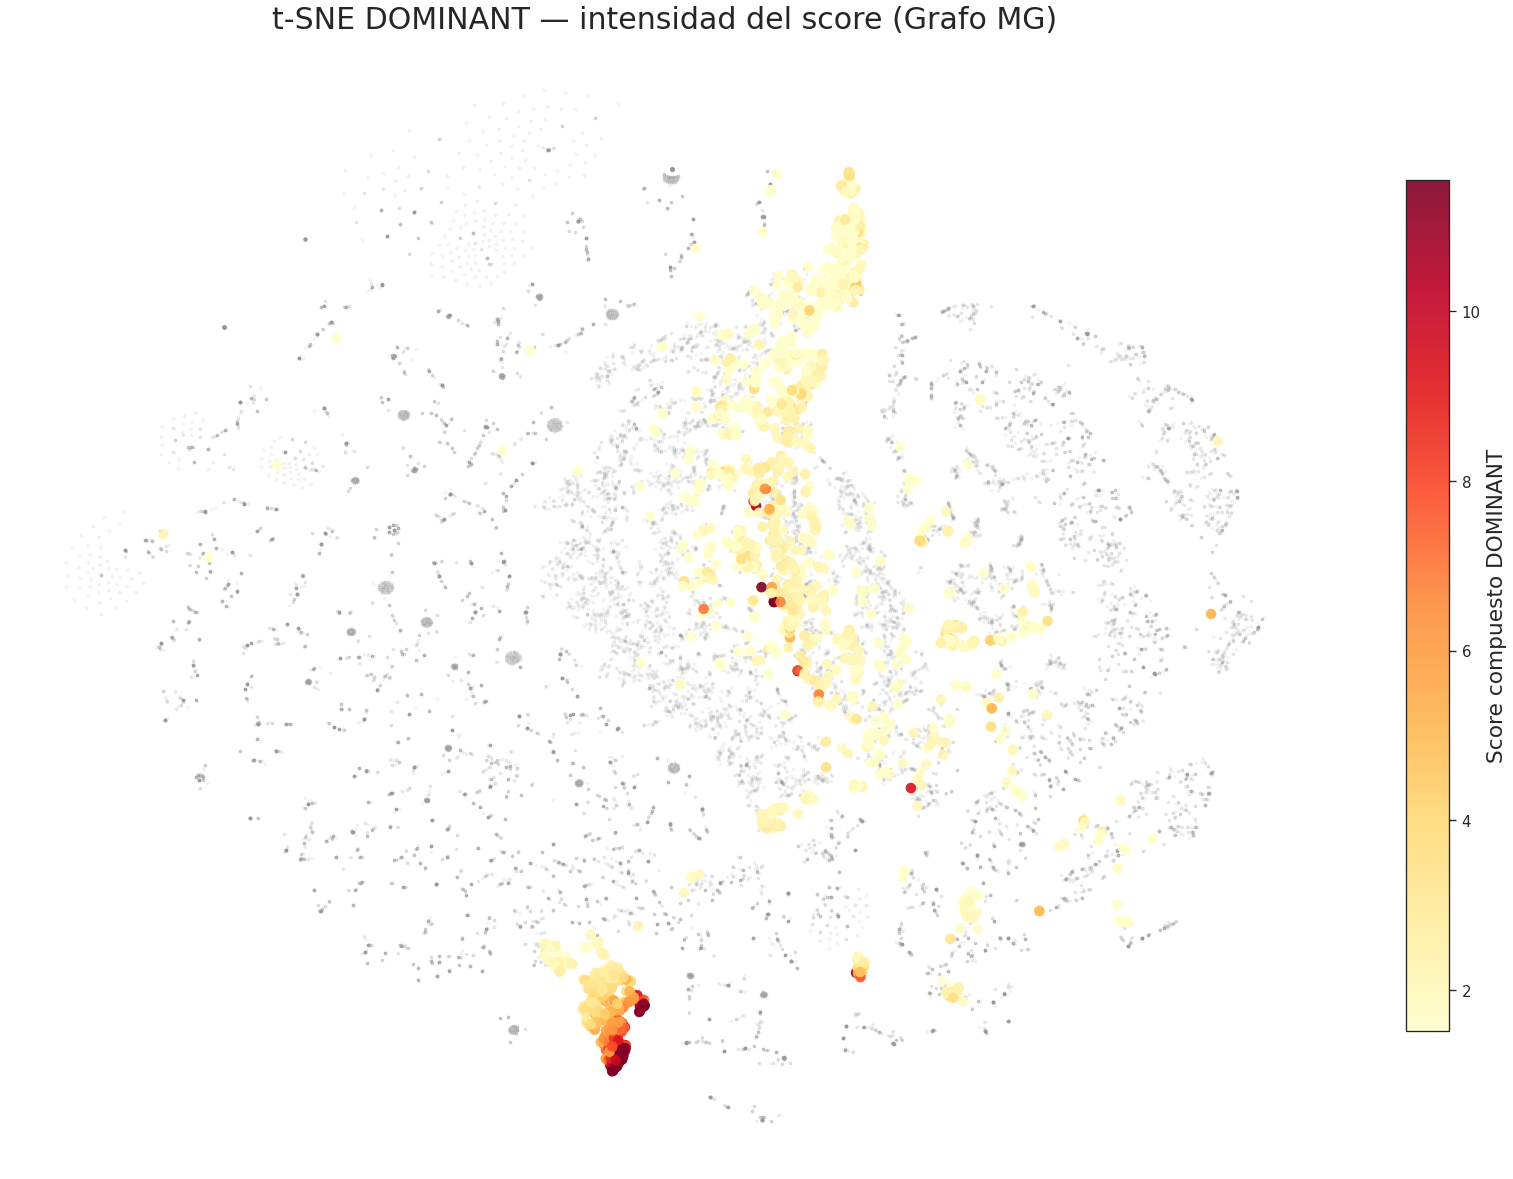

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_profile_MG.png


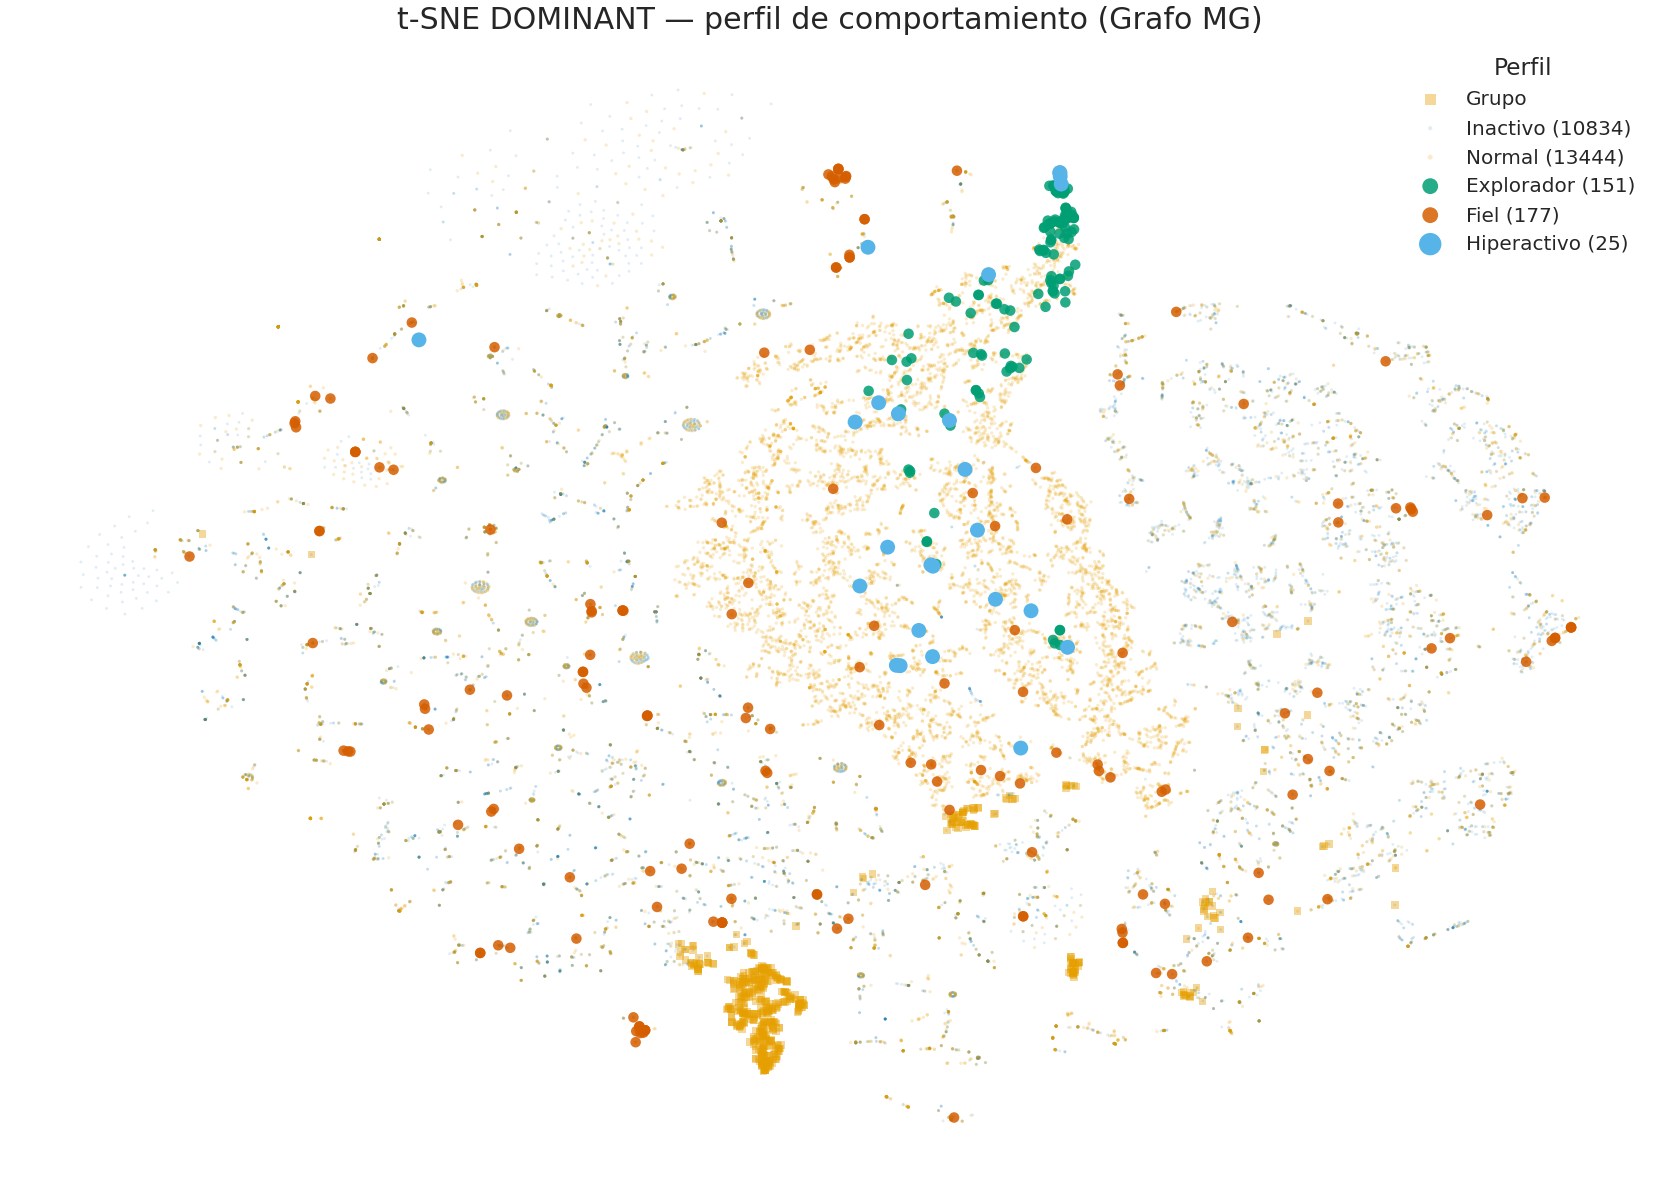

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_degree_MG.png


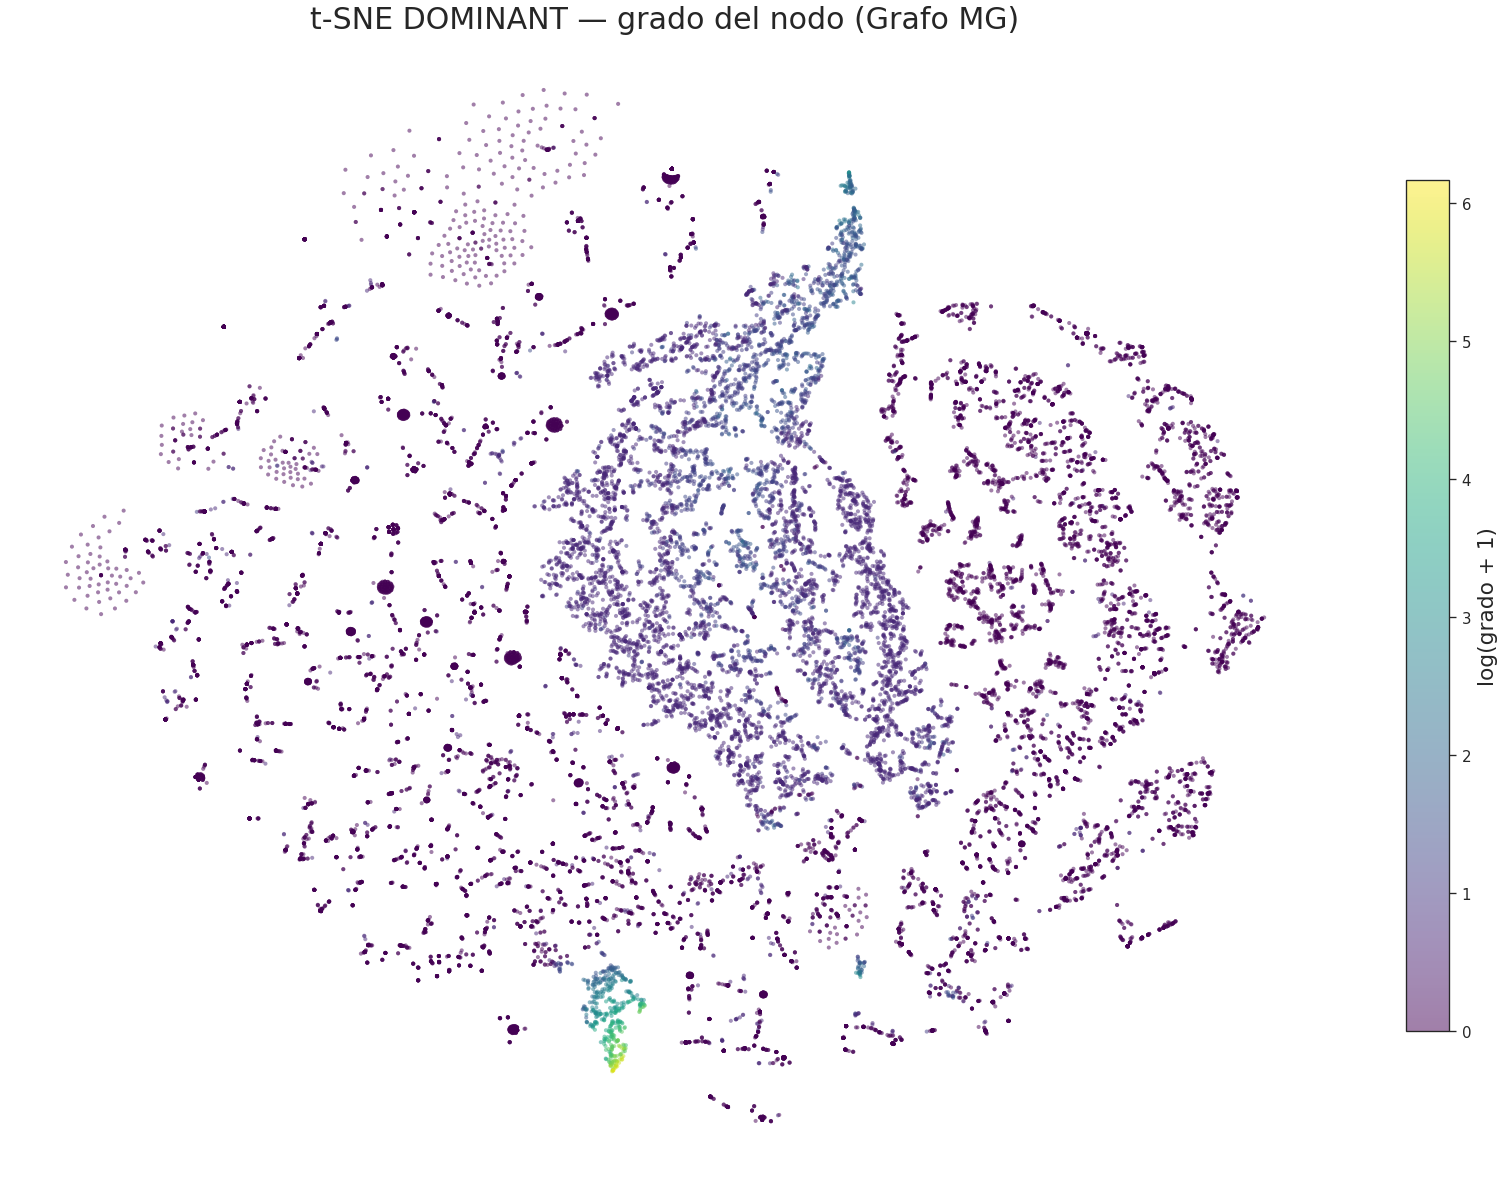

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_node_type_MG.png


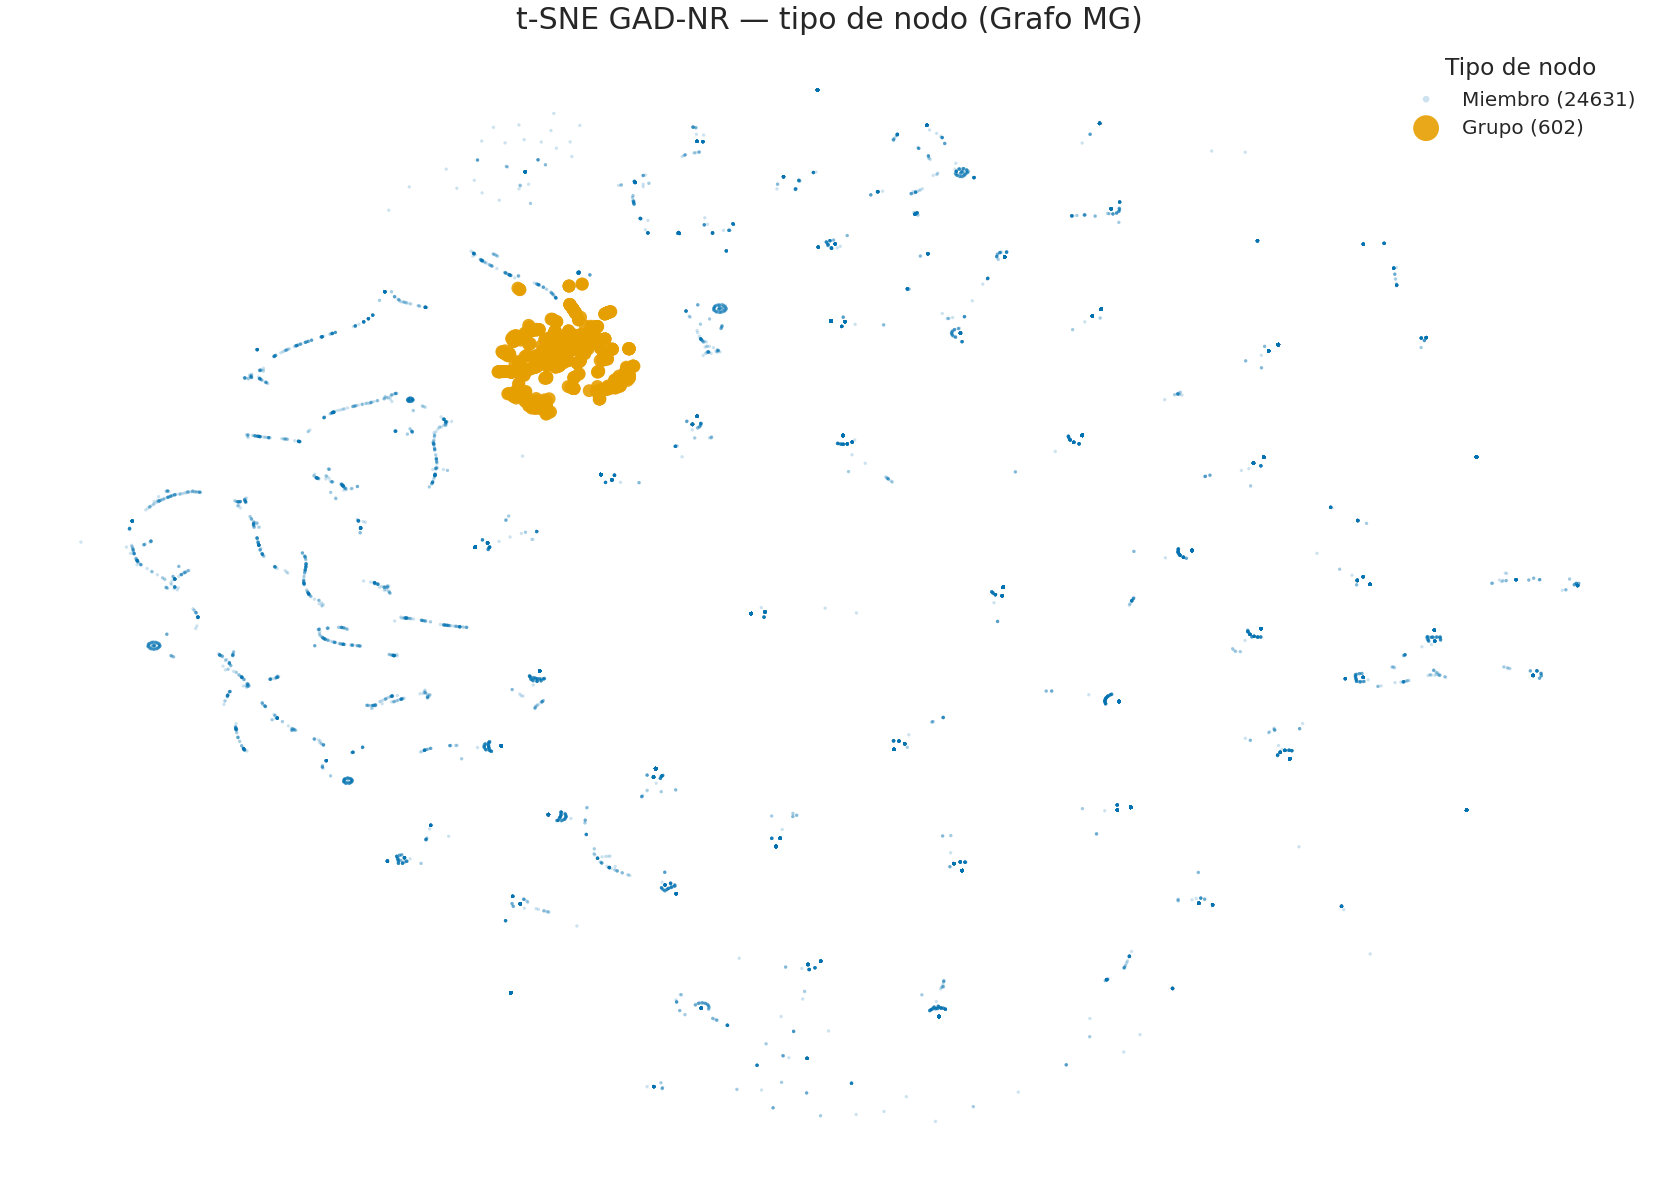

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_type_MG.png


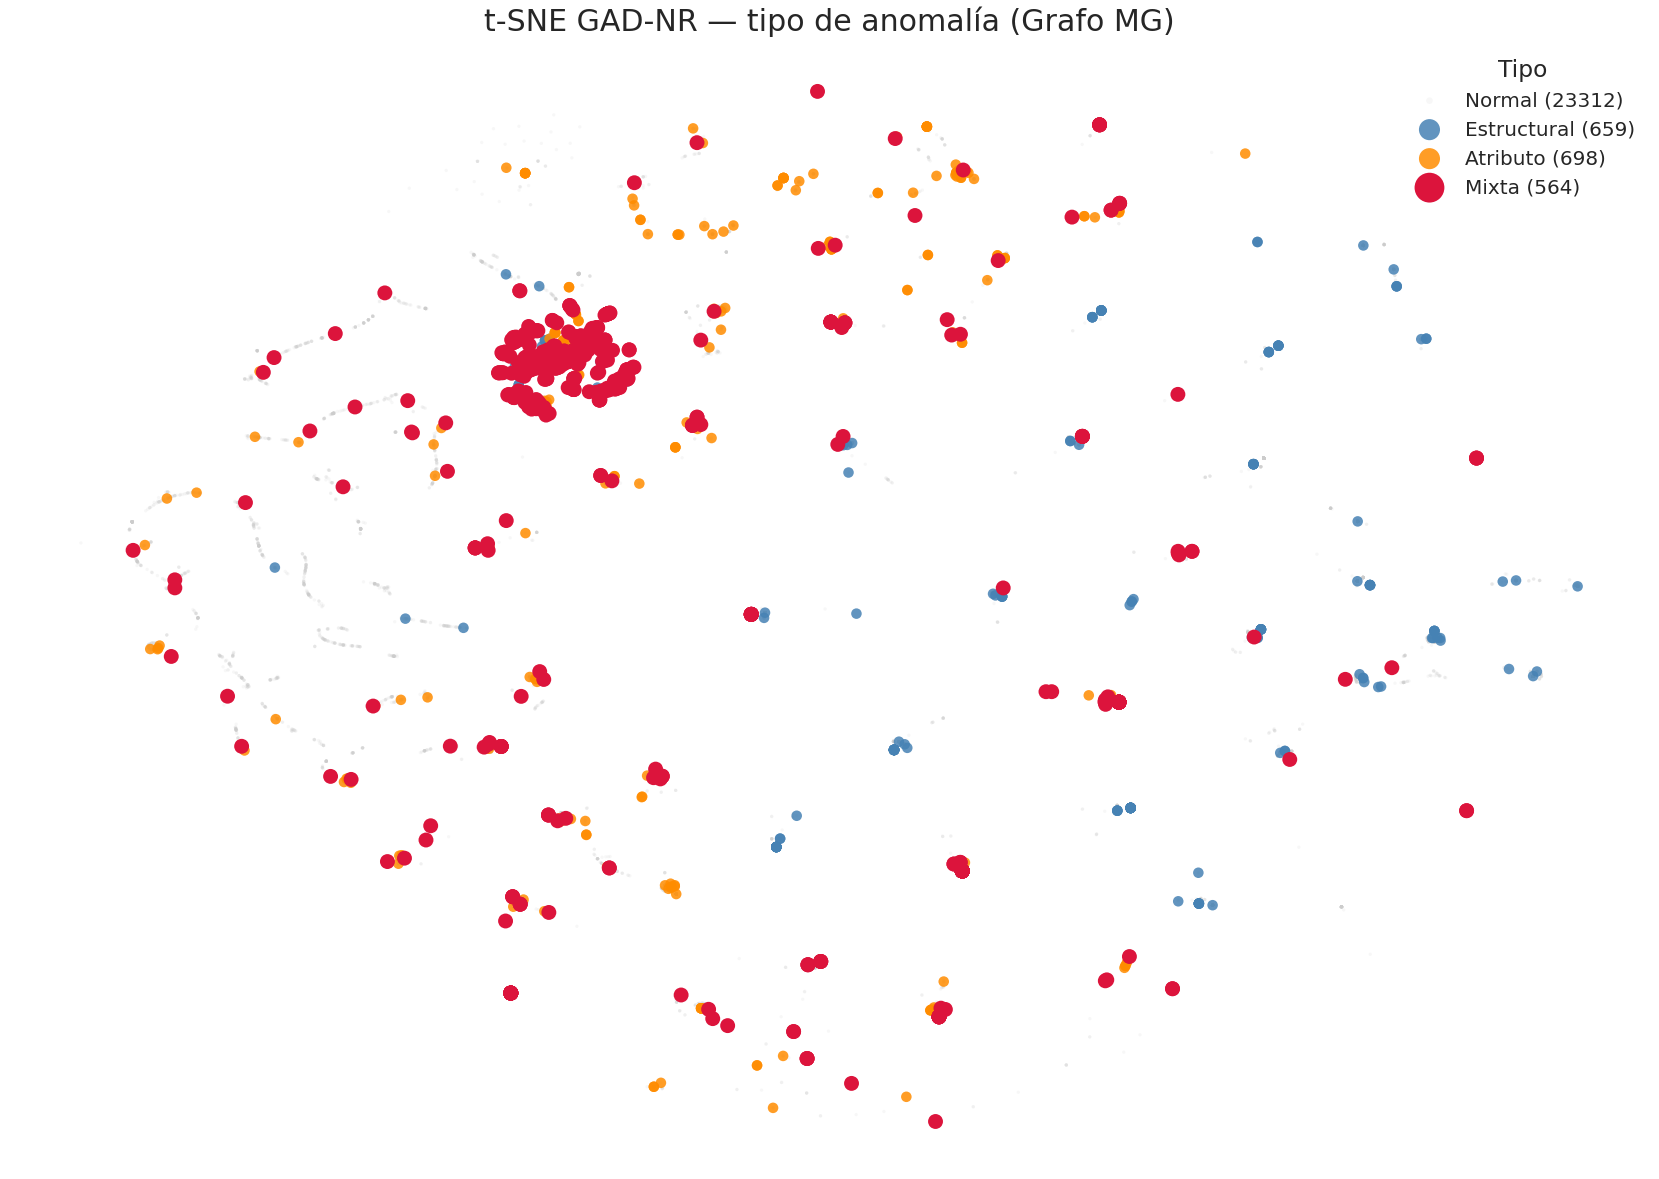

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_score_MG.png


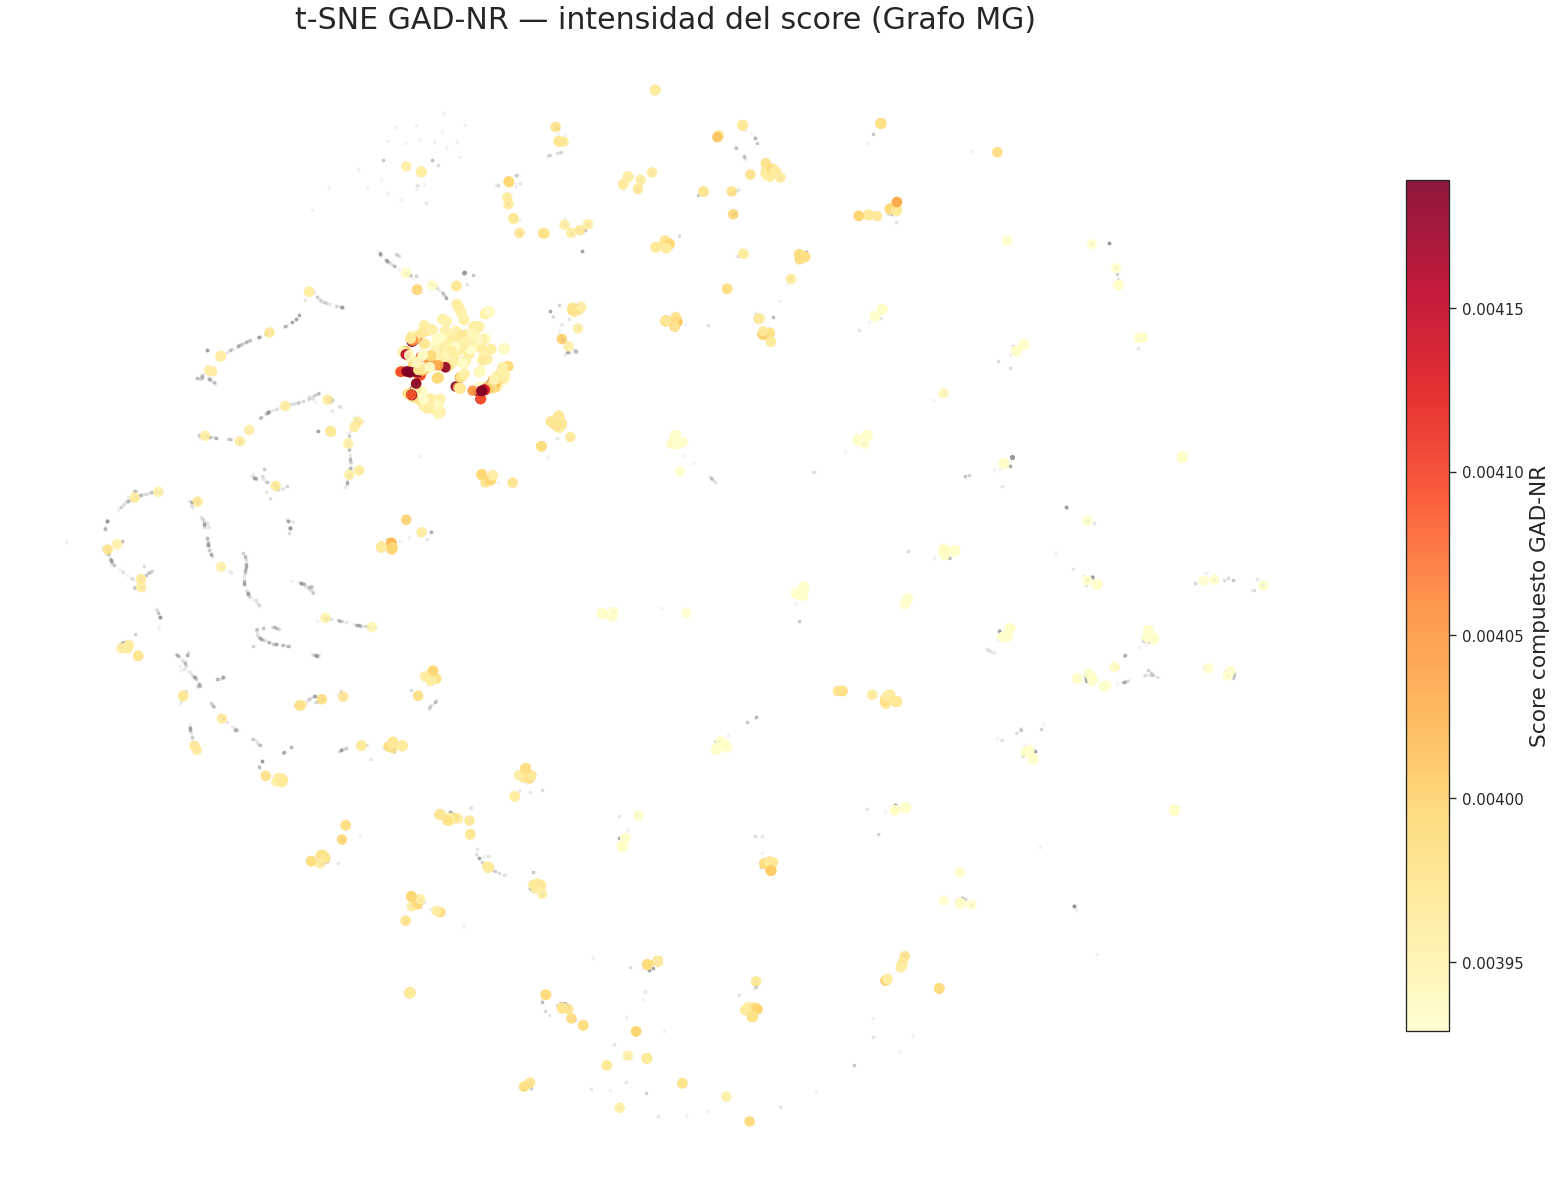

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_profile_MG.png


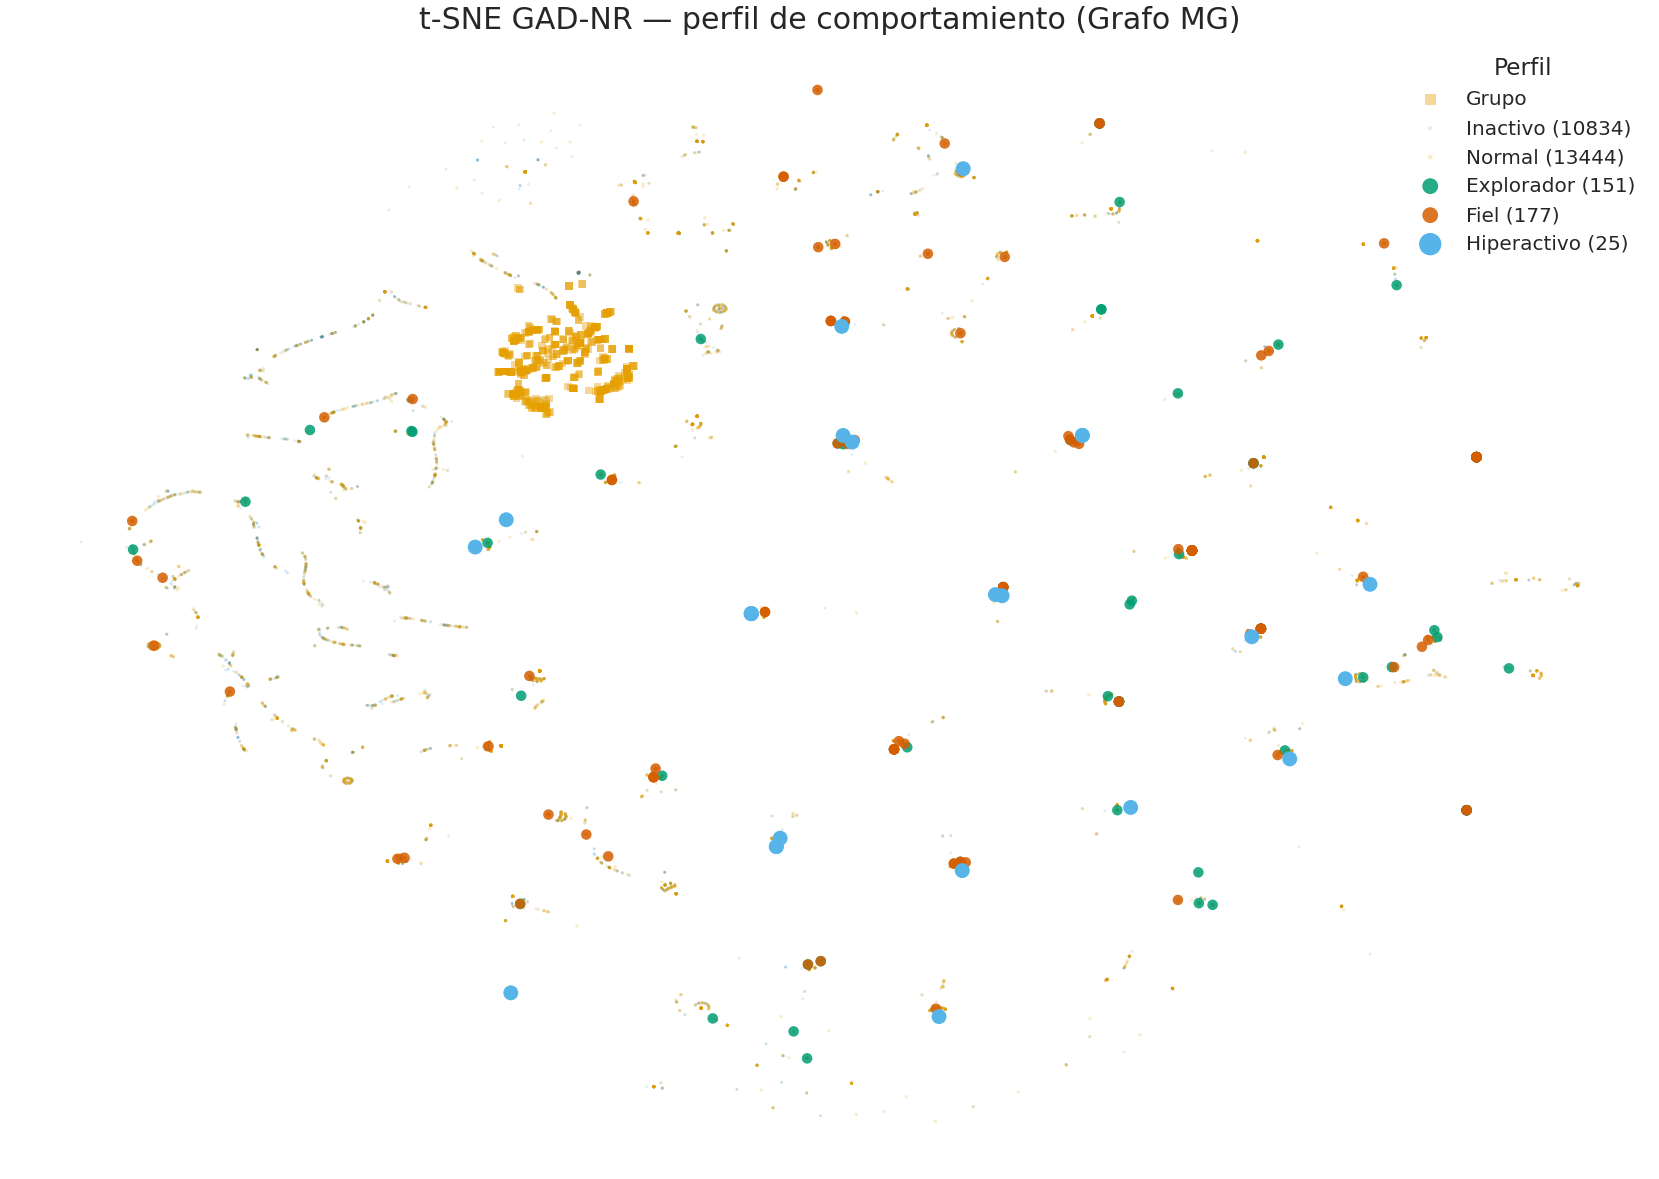

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_degree_MG.png


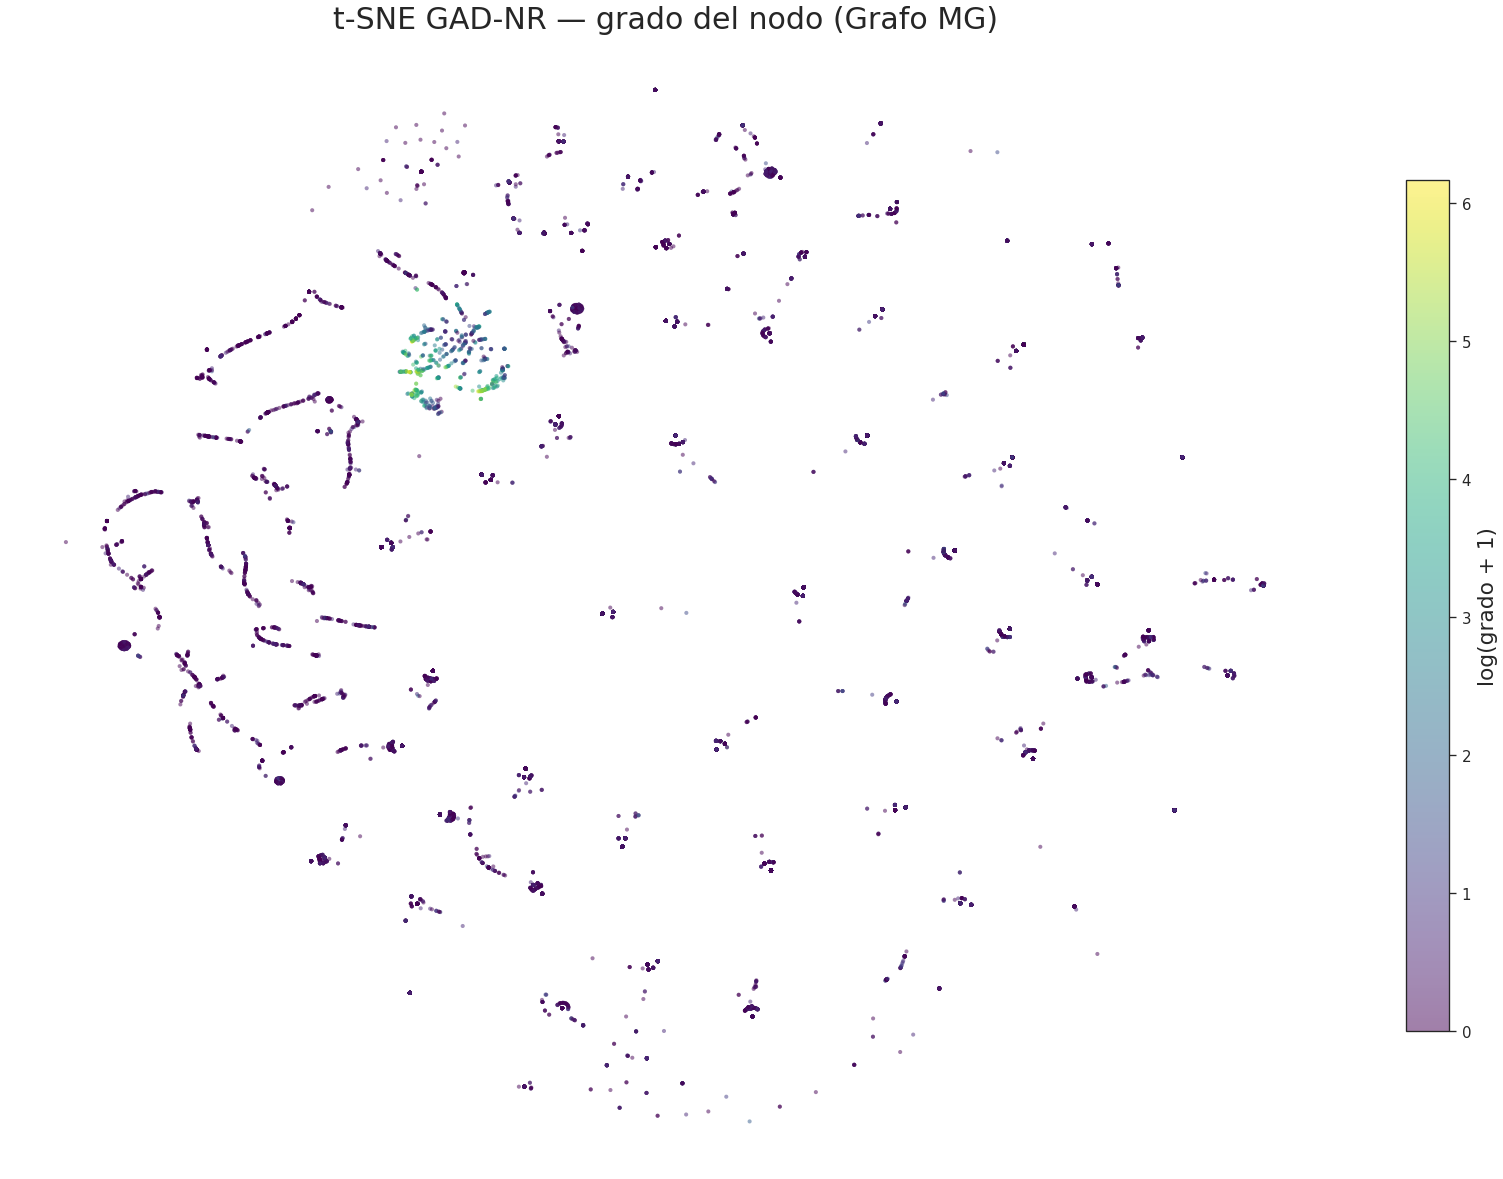

In [78]:
def plot_tsne_panel_mg(tsne_coords, scores_df, model_name, type_col, score_col,
                       figname_prefix, members_scores_df=None):
    """Genera las cinco vistas t-SNE para el grafo MG."""
    FONT_TSNE = {'title': 18, 'axis_label': 13, 'legend': 12, 'annotation': 10}

    def remove_all_spines(ax):
        for spine in ax.spines.values():
            spine.set_visible(False)

    is_member = (scores_df['node_type'] == 'member').values
    is_group  = (scores_df['node_type'] == 'group').values

    # ── Vista 1: tipo de nodo ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[is_member, 0], tsne_coords[is_member, 1],
               s=4, alpha=0.20, color=PALETTE['M'], label=f'Miembro ({is_member.sum()})',
               zorder=1, edgecolors='none')
    ax.scatter(tsne_coords[is_group, 0], tsne_coords[is_group, 1],
               s=60, alpha=0.90, color=PALETTE['G'], label=f'Grupo ({is_group.sum()})',
               zorder=3, edgecolors='none')
    ax.set_title(f't-SNE {model_name} — tipo de nodo (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo de nodo', fontsize=FONT_TSNE['legend'], frameon=False,
              title_fontsize=FONT_TSNE['legend'] + 2, markerscale=2.0, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_node_type_MG.png')
    plt.show()

    # ── Vista 2: tipo de anomalía ─────────────────────────────────────────
    style_by_type = {
        'Normal':      ('#cccccc', 0.15,  4),
        'Estructural': ('steelblue', 0.85, 40),
        'Atributo':    ('darkorange', 0.85, 40),
        'Mixta':       ('crimson', 1.00, 80),
    }
    fig, ax = plt.subplots(figsize=(14, 10))
    for atype in ['Normal', 'Estructural', 'Atributo', 'Mixta']:
        mask = scores_df[type_col] == atype
        color, alpha, size = style_by_type[atype]
        zorder = 1 if atype == 'Normal' else 3
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                   s=size, alpha=alpha, color=color,
                   label=f'{atype} ({mask.sum()})', zorder=zorder, edgecolors='none')
    ax.set_title(f't-SNE {model_name} — tipo de anomalía (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo', fontsize=FONT_TSNE['legend'], frameon=False,
              title_fontsize=FONT_TSNE['legend'] + 2, markerscale=2.0, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_type_MG.png')
    plt.show()

    # ── Vista 3: score compuesto ──────────────────────────────────────────
    anom_mask   = scores_df[type_col] != 'Normal'
    normal_mask = ~anom_mask
    vmin_val = scores_df.loc[anom_mask, score_col].quantile(0.20)
    vmax_val = scores_df.loc[anom_mask, score_col].quantile(0.98)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[normal_mask, 0], tsne_coords[normal_mask, 1],
               s=3, alpha=0.10, color=PALETTE['neutral'], zorder=1)
    sc = ax.scatter(
        tsne_coords[anom_mask, 0], tsne_coords[anom_mask, 1],
        c=scores_df.loc[anom_mask, score_col],
        s=40, alpha=0.90, cmap=CMAP_HEAT, zorder=3,
        vmin=vmin_val, vmax=vmax_val, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label(f'Score compuesto {model_name}', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — intensidad del score (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_score_MG.png')
    plt.show()

    # ── Vista 4: perfil de comportamiento (miembros) ──────────────────────
    if members_scores_df is not None:
        perfil_colors_tsne = {
            'Inactivo':    CAT_COLORS[0],
            'Normal':      CAT_COLORS[1],
            'Explorador':  CAT_COLORS[2],
            'Fiel':        CAT_COLORS[3],
            'Hiperactivo': CAT_COLORS[4],
        }
        perfil_sizes = {
            'Inactivo': 3, 'Normal': 4, 'Explorador': 40,
            'Fiel': 40, 'Hiperactivo': 80
        }
        perfil_alphas = {
            'Inactivo': 0.12, 'Normal': 0.20, 'Explorador': 0.85,
            'Fiel': 0.85, 'Hiperactivo': 1.00
        }

        fig, ax = plt.subplots(figsize=(14, 10))
        # Grupos en gris de fondo
        ax.scatter(tsne_coords[is_group, 0], tsne_coords[is_group, 1],
                   s=20, alpha=0.40, color=PALETTE['G'],
                   label='Grupo', zorder=1, edgecolors='none', marker='s')

        for perfil in ['Inactivo', 'Normal', 'Explorador', 'Fiel', 'Hiperactivo']:
            member_idxs = members_scores_df[members_scores_df['perfil'] == perfil]['idx'].values
            mask = np.isin(np.arange(len(scores_df)), member_idxs)
            if mask.sum() == 0:
                continue
            ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                       s=perfil_sizes[perfil], alpha=perfil_alphas[perfil],
                       color=perfil_colors_tsne[perfil],
                       label=f'{perfil} ({mask.sum()})',
                       zorder=3 if perfil != 'Inactivo' else 2,
                       edgecolors='none')

        ax.set_title(f't-SNE {model_name} — perfil de comportamiento (Grafo MG)',
                     fontsize=FONT_TSNE['title'])
        ax.legend(title='Perfil', fontsize=FONT_TSNE['legend'], frameon=False,
                  title_fontsize=FONT_TSNE['legend'] + 2, markerscale=1.5, loc='upper right')
        ax.set_xticks([]); ax.set_yticks([])
        remove_all_spines(ax)
        plt.tight_layout()
        save_figure(fig, f'{figname_prefix}_tsne_profile_MG.png')
        plt.show()

    # ── Vista 5: grado del nodo ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    sc = ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c=np.log1p(scores_df['degree']),
        s=6, alpha=0.50, cmap=CMAP_SEQ, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label('log(grado + 1)', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — grado del nodo (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_degree_MG.png')
    plt.show()


# t-SNE DOMINANT
plot_tsne_panel_mg(
    tsne_coords=tsne_dom,
    scores_df=scores_df,
    model_name='DOMINANT',
    type_col='type_dom',
    score_col='dom_combined',
    figname_prefix='07_dominant',
    members_scores_df=members_scores,
)

# t-SNE GAD-NR
plot_tsne_panel_mg(
    tsne_coords=tsne_gadnr,
    scores_df=scores_df,
    model_name='GAD-NR',
    type_col='type_gadnr',
    score_col='gadnr_score',
    figname_prefix='07_gadnr',
    members_scores_df=members_scores,
)


## 10. Guardado de resultados

In [41]:
cols_export = [
    'idx', 'node_id', 'node_type', 'raw_id', 'name', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
    # Peso medio de arista (actividad real)
    'mean_edge_weight',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_MG.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_MG.csv')
print(f'Shape    : {scores_export.shape}')

np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_MG.npz'),
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
    node_ids=np.array(node_ids),
)
print(f'Guardado : {RESULTS_PATH}embeddings_MG.npz')


Guardado : ../data/results/scores_MG.csv
Shape    : (25233, 21)
Guardado : ../data/results/embeddings_MG.npz


## Resumen del notebook

Sección a completar tras la ejecución. Los puntos a documentar son:

1. Convergencia del entrenamiento de DOMINANT y rangos de `dom_struct`/`dom_attr`.
2. Convergencia de GAD-NR, lambdas finales y estado de los sub-scores.
3. Correlación Spearman y Jaccard P95 entre señales estructurales y de atributo.
4. Distribución de tipologías por tipo de nodo (miembros vs grupos).
5. Resultados del spotlight de candidatos individuales.
6. Hallazgos del análisis enriquecido:
   - ¿Qué perfil de comportamiento tiene mayor fracción de anomalías detectadas?
   - ¿Los grupos fantasma tienen scores de atributo altos?
   - ¿Existe correlación entre peso medio de arista y score de anomalía?
7. ¿Separa el t-SNE los dos tipos de nodo? ¿Y los perfiles de comportamiento?
8. Comparativa M vs G vs MG.

Los resultados quedan en `scores_MG.csv` (25.233 nodos × 21 columnas) y `embeddings_MG.npz`.


In [44]:
import pickle
import torch
import numpy as np
import pandas as pd
import os

SAVE_PATH = '../data/results/models/'
os.makedirs(SAVE_PATH, exist_ok=True)

# ── DOMINANT — pickle completo ────────────────────────────────────────────
with open(os.path.join(SAVE_PATH, 'dominant_MG.pkl'), 'wb') as f:
    pickle.dump(dominant, f)
print('DOMINANT guardado.')

# ── GAD-NR — state_dict + atributos (Pool no es serializable) ────────────
torch.save(gadnr.model.state_dict(), os.path.join(SAVE_PATH, 'gadnr_model_MG.pt'))
gadnr_attrs = {
    'decision_score_':   gadnr.decision_score_.cpu(),
    'label_':            gadnr.label_.cpu(),
    'lambda_loss1':      gadnr.model.lambda_loss1,
    'lambda_loss2':      gadnr.model.lambda_loss2,
    'lambda_loss3':      gadnr.model.lambda_loss3,
    'neighbor_num_list': gadnr.neighbor_num_list.cpu(),
}
torch.save(gadnr_attrs, os.path.join(SAVE_PATH, 'gadnr_attrs_MG.pt'))
print('GAD-NR guardado.')

# ── Arrays derivados ──────────────────────────────────────────────────────
np.savez(
    os.path.join(SAVE_PATH, 'arrays_MG.npz'),
    dom_struct=dom_struct,
    dom_attr=dom_attr,
    gadnr_h=gadnr_h,
    gadnr_deg=gadnr_deg,
    gadnr_feat=gadnr_feat,
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
)
print('Arrays guardados.')

# ── DataFrames ────────────────────────────────────────────────────────────
scores_df.to_csv(os.path.join(SAVE_PATH, 'scores_df_MG.csv'), index=False)
members_scores.to_csv(os.path.join(SAVE_PATH, 'members_scores_MG.csv'), index=False)
groups_scores.to_csv(os.path.join(SAVE_PATH, 'groups_scores_MG.csv'), index=False)
print('DataFrames guardados.')

print(f'\nTodo guardado en {SAVE_PATH}')
print(f'  dominant_MG.pkl')
print(f'  gadnr_model_MG.pt + gadnr_attrs_MG.pt')
print(f'  arrays_MG.npz')
print(f'  scores_df_MG.csv')
print(f'  members_scores_MG.csv')
print(f'  groups_scores_MG.csv')

DOMINANT guardado.
GAD-NR guardado.
Arrays guardados.
DataFrames guardados.

Todo guardado en ../data/results/models/
  dominant_MG.pkl
  gadnr_model_MG.pt + gadnr_attrs_MG.pt
  arrays_MG.npz
  scores_df_MG.csv
  members_scores_MG.csv
  groups_scores_MG.csv


In [ ]:
import pickle
import torch
import numpy as np
import pandas as pd
import os

SAVE_PATH = '../data/results/models/'

# ── DOMINANT — pickle completo ────────────────────────────────────────────
with open(os.path.join(SAVE_PATH, 'dominant_MG.pkl'), 'rb') as f:
    dominant = pickle.load(f)
print('DOMINANT cargado.')

# ── GAD-NR — reinstanciar y cargar pesos ─────────────────────────────────
# IMPORTANTE: necesitas tener el objeto gadnr ya instanciado con los mismos
# hiperparámetros y haber ejecutado gadnr.fit() al menos 1 época antes
# de ejecutar estas líneas para que PyGOD inicialice la arquitectura interna
gadnr_attrs = torch.load(os.path.join(SAVE_PATH, 'gadnr_attrs_MG.pt'))
gadnr.model.load_state_dict(
    torch.load(os.path.join(SAVE_PATH, 'gadnr_model_MG.pt'))
)
gadnr.decision_score_    = gadnr_attrs['decision_score_'].to(device)
gadnr.label_             = gadnr_attrs['label_'].to(device)
gadnr.model.lambda_loss1 = gadnr_attrs['lambda_loss1']
gadnr.model.lambda_loss2 = gadnr_attrs['lambda_loss2']
gadnr.model.lambda_loss3 = gadnr_attrs['lambda_loss3']
gadnr.neighbor_num_list  = gadnr_attrs['neighbor_num_list'].to(device)
print('GAD-NR cargado.')

# ── Arrays derivados ──────────────────────────────────────────────────────
arrays     = np.load(os.path.join(SAVE_PATH, 'arrays_MG.npz'))
dom_struct = arrays['dom_struct']
dom_attr   = arrays['dom_attr']
gadnr_h    = arrays['gadnr_h']
gadnr_deg  = arrays['gadnr_deg']
gadnr_feat = arrays['gadnr_feat']
emb_dom    = arrays['emb_dom']
emb_gadnr  = arrays['emb_gadnr']
tsne_dom   = arrays['tsne_dom']
tsne_gadnr = arrays['tsne_gadnr']
print('Arrays cargados.')

# ── DataFrames ────────────────────────────────────────────────────────────
scores_df      = pd.read_csv(os.path.join(SAVE_PATH, 'scores_df_MG.csv'))
members_scores = pd.read_csv(os.path.join(SAVE_PATH, 'members_scores_MG.csv'))
groups_scores  = pd.read_csv(os.path.join(SAVE_PATH, 'groups_scores_MG.csv'))
print('DataFrames cargados.')

print(f'\nTodo cargado correctamente.')
print(f'  DOM scores : {dom_struct.shape}')
print(f'  GADNR scores: {gadnr_h.shape}')
print(f'  scores_df  : {scores_df.shape}')
print(f'  members_df : {members_scores.shape}')
print(f'  groups_df  : {groups_scores.shape}')
print(f'  emb_dom    : {emb_dom.shape}')
print(f'  tsne_dom   : {tsne_dom.shape}')